### Librerias

In [148]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re


In [149]:
# Ruta donde están los archivos
#Ruta Local Fabian
#ruta = r"C:\Users\fabil\Downloads"
#Ruta Local Maleja
ruta = r"C:\Users\madelgado\OneDrive - Universidad de los andes\Materias MIAD\12_Despliegue de soluciones analíticas\Proyecto\ProyectoFabian\Proyecto---Despliegue-de-Soluciones-Analiticas"

# Archivos
archivos_clientes = [
    "TC1_07_2025_CELSIA_VALLE_V2.csv",
    "TC1_08_2025_CELSIA_VALLE_V2.csv"
]

archivos_indicadores = [
    "Compensacion_2025_07.csv",
    "Compensacion_2025_08.csv"
]

# --- Cargar bases de CLIENTES ---
# --- Cargar bases de CLIENTES ---
clientes = pd.concat(
    [
        pd.read_csv(
            os.path.join(ruta, archivo),
            sep=',',
            encoding='utf-8',
            dtype={"NIU": str},          
            low_memory=False
        )
        # Extraer el PERIODO desde el nombre del archivo (ej: 07_2025)
        .assign(
            archivo_origen=archivo,
            tipo_base="clientes",
            PERIODO=pd.to_datetime(
                re.search(r'(\d{2}_\d{4})', archivo).group(1),
                format='%m_%Y'
            )
        )
        for archivo in archivos_clientes
    ],
    ignore_index=True
)       

# Ajustar formato del PERIODO a texto YYYY-MM
clientes['PERIODO'] = clientes['PERIODO'].dt.strftime('%Y-%m')

# --- Cargar bases de INDICADORES ---
indicadores = pd.concat(
    [
        pd.read_csv(
            os.path.join(ruta, archivo),
            sep=';',
            encoding='utf-8',
            dtype={"NIU": str},
            low_memory=False
        ).assign(archivo_origen=archivo)
        for archivo in archivos_indicadores
    ],
    ignore_index=True
)
indicadores["tipo_base"] = "indicadores"

# Alinear formato de periodo
indicadores['PERIODO'] = pd.to_datetime(indicadores['PERIODO'], errors='coerce').dt.strftime('%Y-%m')

print(clientes[['NIU','PERIODO']].head())
print(indicadores[['NIU','PERIODO']].head())

# --- Limpieza de nombres de columnas ---
clientes.columns = clientes.columns.str.strip().str.upper().str.replace(" ", "_")
indicadores.columns = indicadores.columns.str.strip().str.upper().str.replace(" ", "_")

# --- Unión por NIU ---
#df_integrado = pd.merge(indicadores, clientes, on="NIU", how="inner")

# --- Resumen final ---
#print("Registros integrados:", df_integrado.shape[0])
#print("Columnas totales:", df_integrado.shape[1])
#print("Ejemplo de NIU:", df_integrado["NIU"].head(5))

# --- Guardar el dataset unificado ---
#df_integrado.to_csv(os.path.join(ruta, "Dataset_Integrado_Compensaciones.csv"), index=False, encoding='utf-8')


           NIU  PERIODO
0      2896755  2025-07
1      3518981  2025-07
2  20230321850  2025-07
3      2949132  2025-07
4      3213681  2025-07
       NIU  PERIODO
0  1000001  2025-07
1  1000005  2025-07
2  1000008  2025-07
3  1000009  2025-07
4  1000011  2025-07


In [113]:
indicadores

,ERROR_EN_METAS,OPERADOR_RED,PERIODO,NIU,DIU,DIUM,FIU,FIUM,HC,DIUG,...,GRUPO_CALIDAD,NIVEL_TENSION,CARGO_DISTRIBUCION,CONSUMO_MES,MES_FACTURADOS,DURA._INTERRUPCIONES,%_PROP._ACTIVO,ID_MERCADO,ARCHIVO_ORIGEN,TIPO_BASE
0,NO,CELSIA VALLE,2025-07,1000001,0.00000,0.00000,0,0,0.0,10.25,...,12,1,398.997,167.0,1,0.00055,100,561,Compensacion_2025_07.csv,indicadores
1,NO,CELSIA VALLE,2025-07,1000005,13.29471,0.00000,4,0,0.0,57.02,...,32,1,398.997,0.0,2,12.93388,100,561,Compensacion_2025_07.csv,indicadores
2,NO,CELSIA VALLE,2025-07,1000008,13.29471,0.00000,4,0,0.0,57.02,...,32,1,398.997,0.0,2,12.93388,100,561,Compensacion_2025_07.csv,indicadores
3,NO,CELSIA VALLE,2025-07,1000009,13.29471,0.00000,4,0,0.0,57.02,...,32,1,398.997,0.0,2,12.93388,100,561,Compensacion_2025_07.csv,indicadores
4,NO,CELSIA VALLE,2025-07,1000011,13.29471,0.00000,4,0,0.0,57.02,...,32,1,398.997,0.0,2,12.93388,100,561,Compensacion_2025_07.csv,indicadores
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1443697,NO,CELSIA VALLE,2025-08,9887654,5.47000,0.00000,4,0,0.0,40.96,...,31,1,398.370,182.0,2,1.33277,100,561,Compensacion_2025_08.csv,indicadores
1443698,NO,CELSIA VALLE,2025-08,990920112578,13.50000,2.20583,27,3,0.0,57.02,...,32,1,398.370,0.0,2,0.00916,100,561,Compensacion_2025_08.csv,indicadores
1443699,NO,CELSIA VALLE,2025-08,993320550,3.50000,0.00000,3,0,0.0,40.96,...,31,1,326.865,0.0,2,0.00972,0,561,Compensacion_2025_08.csv,indicadores
1443700,NO,CELSIA VALLE,2025-08,9945573156,2.91000,0.00000,3,0,0.0,40.96,...,31,1,398.370,0.0,2,3.87860,100,561,Compensacion_2025_08.csv,indicadores


In [114]:
clientes

,NIU,CODIGO_CONEXION,TIPO_CONEXION,NIVEL_TENSION,NIVEL_TENSIÓN_PRIMARIA,PORC_PROP_ACTIV,CONEXION_RED,ID_COMERCIALIZADOR,ID_MERCADO,GRUPO_CALIDAD,...,EXP_ENERGIA,CAPAC_AUTOGEN,TIP_GENERACION,COD_FRONTERA_EXPORT,F_ENTRADA_GENERAR,CONTR_RESPALDO,CAPAC_CONTR_RES,ARCHIVO_ORIGEN,TIPO_BASE,PERIODO
0,2896755,65030128,2,1,2,100,1,536,561,32,...,1.0,12.0,1.0,AGPE0001,07-09-2022,2.0,NaN,TC1_07_2025_CELSIA_VALLE_V2.csv,clientes,2025-07
1,3518981,65005423,2,1,2,100,1,536,561,32,...,1.0,6.0,5.0,AGPE0001,31-12-2020,2.0,NaN,TC1_07_2025_CELSIA_VALLE_V2.csv,clientes,2025-07
2,20230321850,129000000919116,2,1,2,100,1,536,561,32,...,1.0,12.0,1.0,AGPE0001,01-08-2024,2.0,NaN,TC1_07_2025_CELSIA_VALLE_V2.csv,clientes,2025-07
3,2949132,65005489,2,1,2,100,1,536,561,32,...,1.0,1.0,1.0,AGPE0001,31-10-2023,2.0,NaN,TC1_07_2025_CELSIA_VALLE_V2.csv,clientes,2025-07
4,3213681,65724288,2,1,3,100,1,536,561,32,...,1.0,100.0,1.0,AGPE0001,25-06-2024,2.0,NaN,TC1_07_2025_CELSIA_VALLE_V2.csv,clientes,2025-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1469982,4085956,65722646,2,1,2,100,1,62371,561,21,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TC1_08_2025_CELSIA_VALLE_V2.csv,clientes,2025-08
1469983,20230002879,65006411,2,1,2,100,1,62371,561,11,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TC1_08_2025_CELSIA_VALLE_V2.csv,clientes,2025-08
1469984,28003630115,65030701,2,3,0,101,1,62371,561,11,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TC1_08_2025_CELSIA_VALLE_V2.csv,clientes,2025-08
1469985,28003630171,65030701,2,3,0,101,1,62371,561,11,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TC1_08_2025_CELSIA_VALLE_V2.csv,clientes,2025-08


In [115]:
clientes['CAPAC_CONTR_RES'].unique()

array([ nan, 0.01])

In [116]:
indicadores

,ERROR_EN_METAS,OPERADOR_RED,PERIODO,NIU,DIU,DIUM,FIU,FIUM,HC,DIUG,...,GRUPO_CALIDAD,NIVEL_TENSION,CARGO_DISTRIBUCION,CONSUMO_MES,MES_FACTURADOS,DURA._INTERRUPCIONES,%_PROP._ACTIVO,ID_MERCADO,ARCHIVO_ORIGEN,TIPO_BASE
0,NO,CELSIA VALLE,2025-07,1000001,0.00000,0.00000,0,0,0.0,10.25,...,12,1,398.997,167.0,1,0.00055,100,561,Compensacion_2025_07.csv,indicadores
1,NO,CELSIA VALLE,2025-07,1000005,13.29471,0.00000,4,0,0.0,57.02,...,32,1,398.997,0.0,2,12.93388,100,561,Compensacion_2025_07.csv,indicadores
2,NO,CELSIA VALLE,2025-07,1000008,13.29471,0.00000,4,0,0.0,57.02,...,32,1,398.997,0.0,2,12.93388,100,561,Compensacion_2025_07.csv,indicadores
3,NO,CELSIA VALLE,2025-07,1000009,13.29471,0.00000,4,0,0.0,57.02,...,32,1,398.997,0.0,2,12.93388,100,561,Compensacion_2025_07.csv,indicadores
4,NO,CELSIA VALLE,2025-07,1000011,13.29471,0.00000,4,0,0.0,57.02,...,32,1,398.997,0.0,2,12.93388,100,561,Compensacion_2025_07.csv,indicadores
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1443697,NO,CELSIA VALLE,2025-08,9887654,5.47000,0.00000,4,0,0.0,40.96,...,31,1,398.370,182.0,2,1.33277,100,561,Compensacion_2025_08.csv,indicadores
1443698,NO,CELSIA VALLE,2025-08,990920112578,13.50000,2.20583,27,3,0.0,57.02,...,32,1,398.370,0.0,2,0.00916,100,561,Compensacion_2025_08.csv,indicadores
1443699,NO,CELSIA VALLE,2025-08,993320550,3.50000,0.00000,3,0,0.0,40.96,...,31,1,326.865,0.0,2,0.00972,0,561,Compensacion_2025_08.csv,indicadores
1443700,NO,CELSIA VALLE,2025-08,9945573156,2.91000,0.00000,3,0,0.0,40.96,...,31,1,398.370,0.0,2,3.87860,100,561,Compensacion_2025_08.csv,indicadores


### Exploración de datos

En la siguiente sección se hace una revisión de las fuentes de información

=== EXPLORACIÓN DE LA BASE DE INDICADORES ===

Número de columnas numéricas reales: 18
Número de columnas categóricas: 12
Total de valores faltantes: 0

Estadísticas descriptivas de las variables numéricas:
                             count         mean            std     min  \
DIU                      1443702.0     8.804445      18.018522   0.000   
DIUM                     1443702.0     0.727255       3.031845   0.000   
FIU                      1443702.0     6.396182       7.292466   0.000   
FIUM                     1443702.0     0.473957       1.020234   0.000   
HC                       1443702.0     0.177384       1.881975   0.000   
DIUG                     1443702.0    23.214870      18.043786   0.000   
FIUG                     1443702.0    15.608844       6.528074   0.000   
VC                       1443702.0     0.059821       0.513423   0.000   
TVC                      1443702.0     0.541496       3.117124   0.000   
THC                      1443702.0     1.872627      

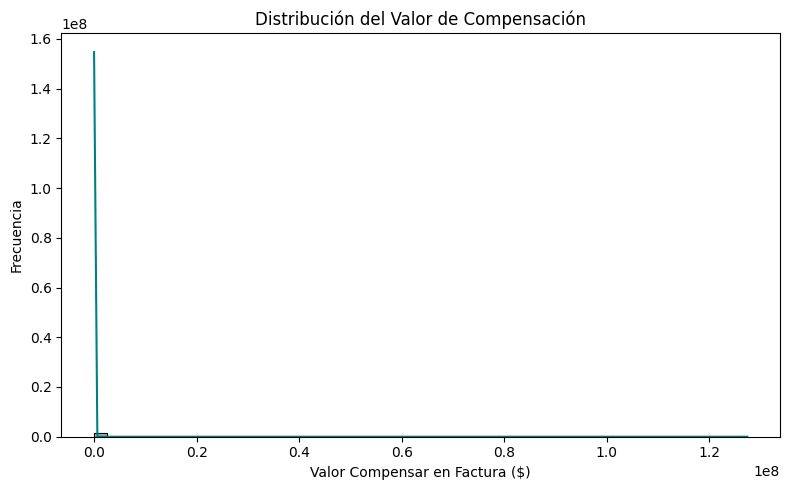

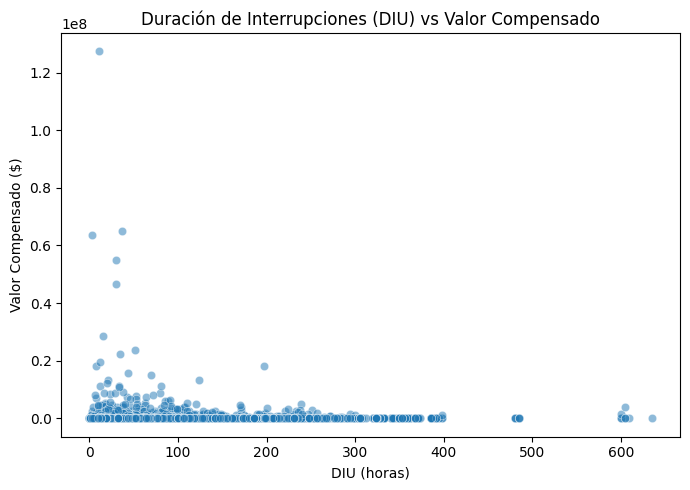

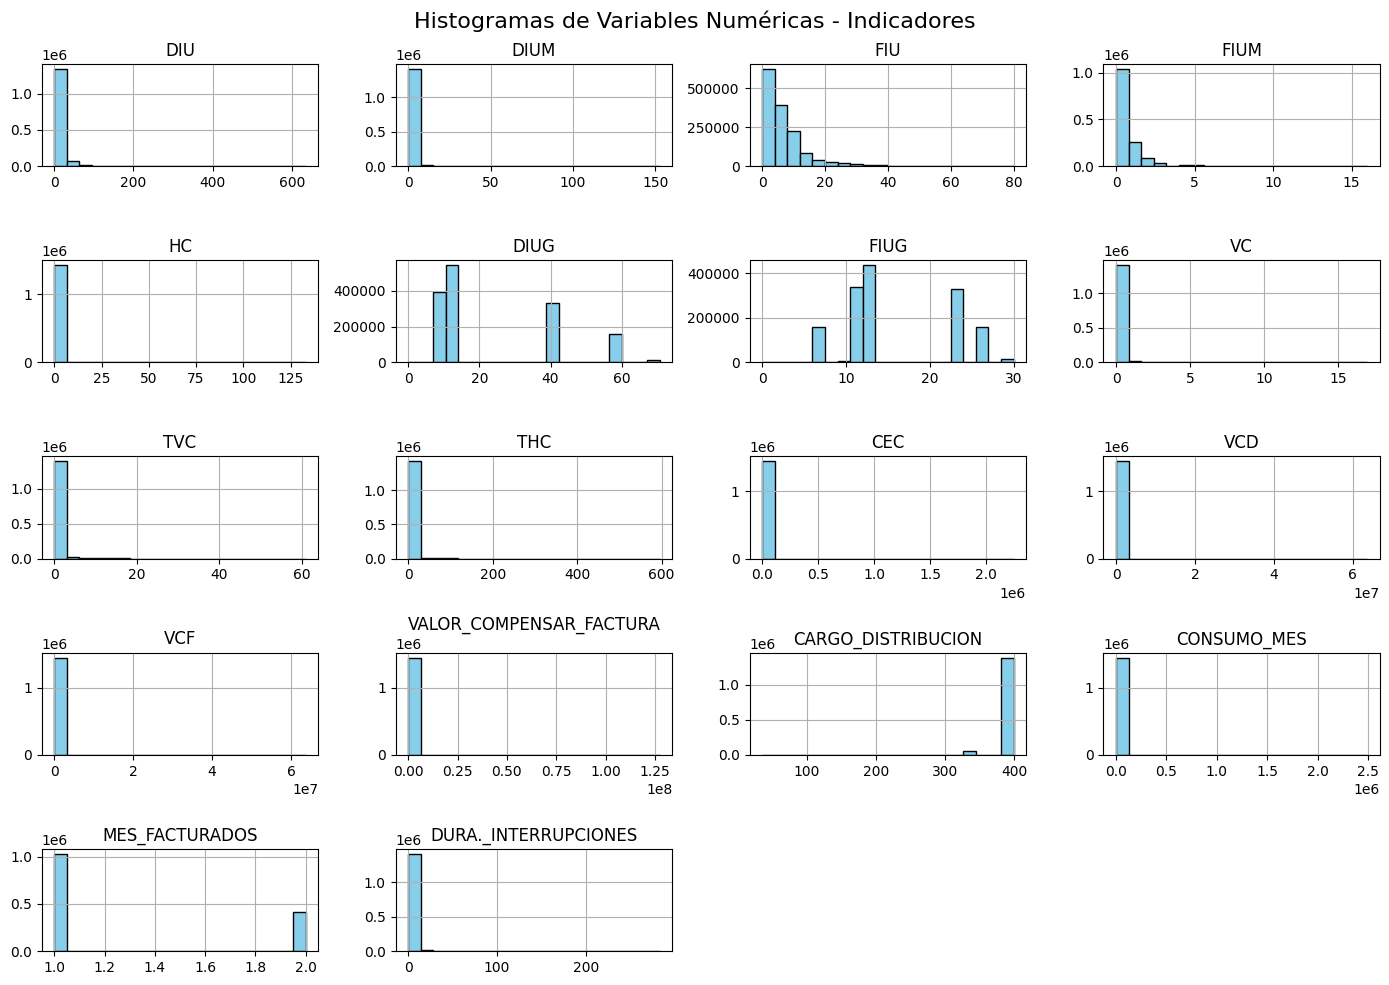


Generando gráficos de frecuencia para las variables categóricas...


C:\Users\madelgado\AppData\Local\Temp\ipykernel_25508\1256154882.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='coolwarm')


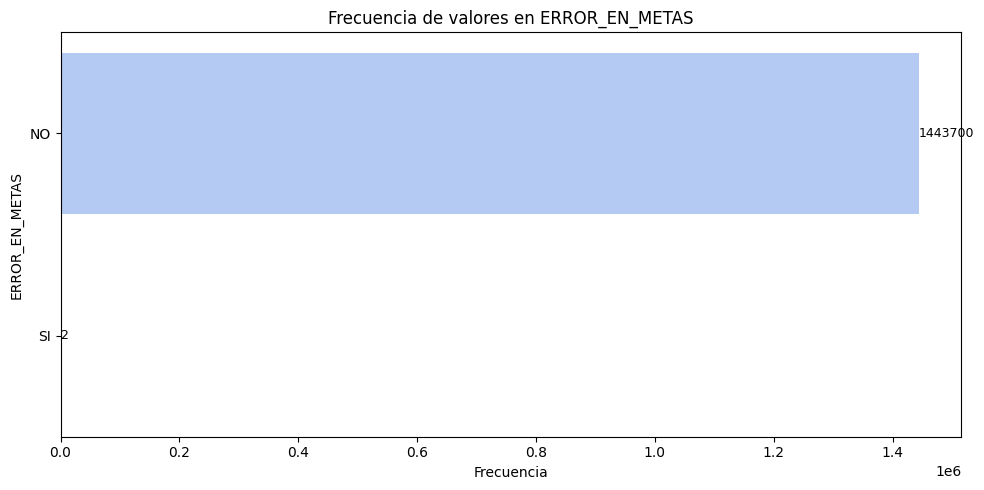

C:\Users\madelgado\AppData\Local\Temp\ipykernel_25508\1256154882.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='coolwarm')


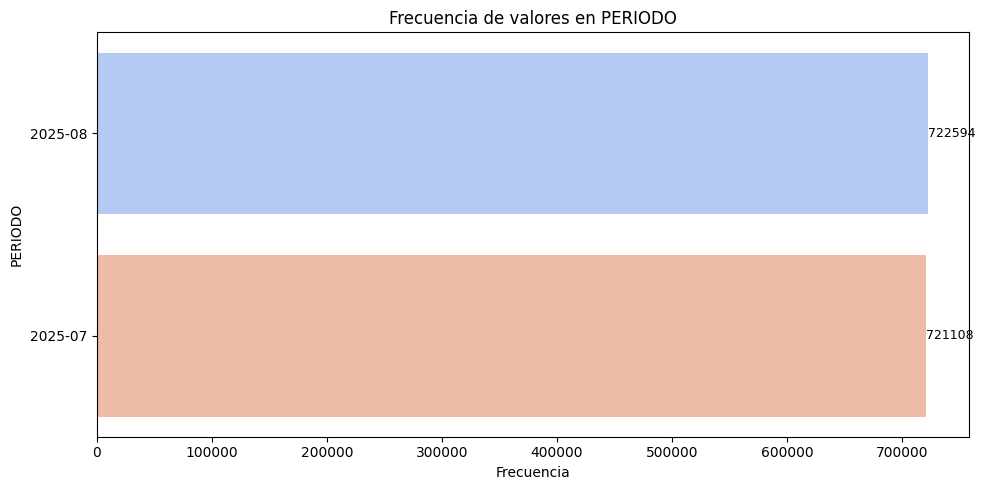

C:\Users\madelgado\AppData\Local\Temp\ipykernel_25508\1256154882.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='coolwarm')


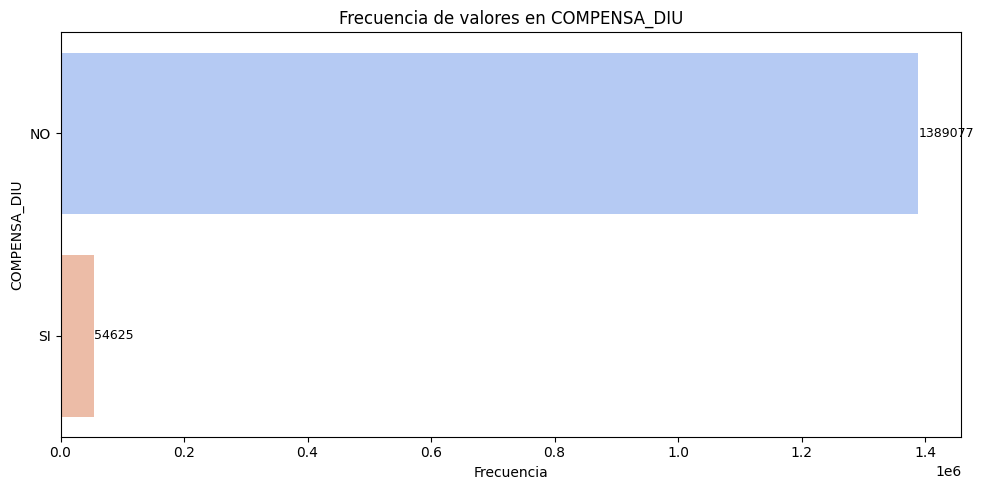

C:\Users\madelgado\AppData\Local\Temp\ipykernel_25508\1256154882.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='coolwarm')


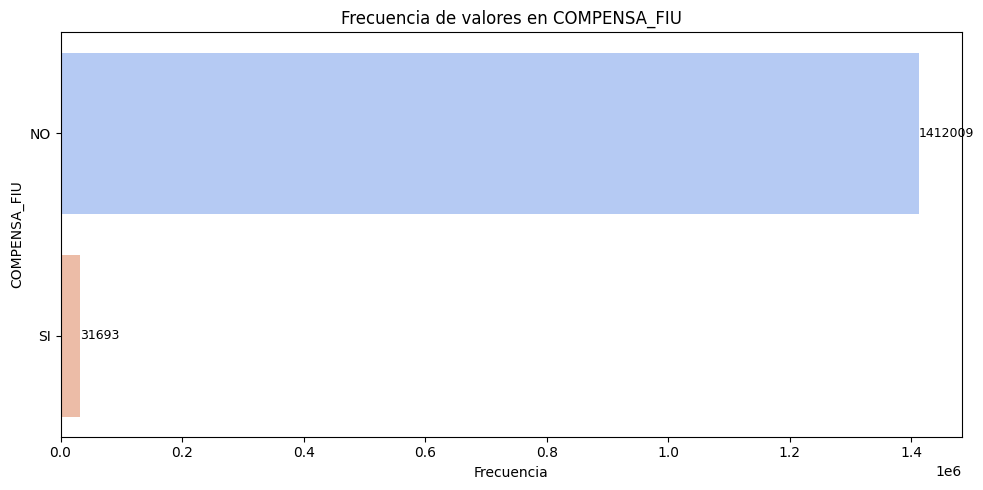

C:\Users\madelgado\AppData\Local\Temp\ipykernel_25508\1256154882.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='coolwarm')


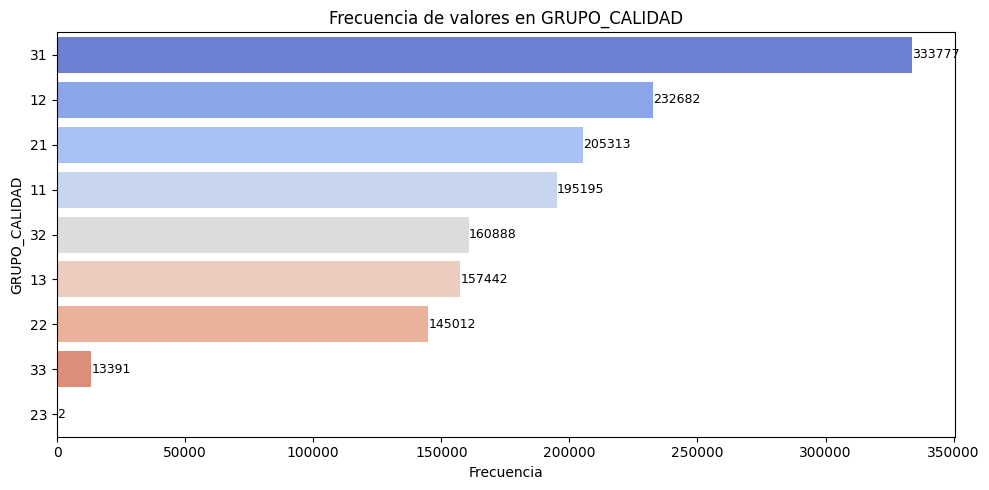

C:\Users\madelgado\AppData\Local\Temp\ipykernel_25508\1256154882.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='coolwarm')


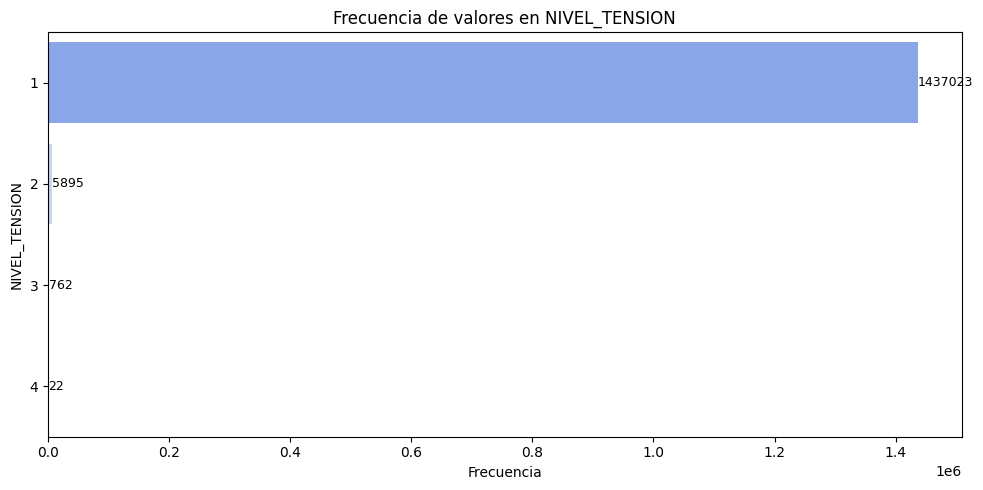

C:\Users\madelgado\AppData\Local\Temp\ipykernel_25508\1256154882.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='coolwarm')


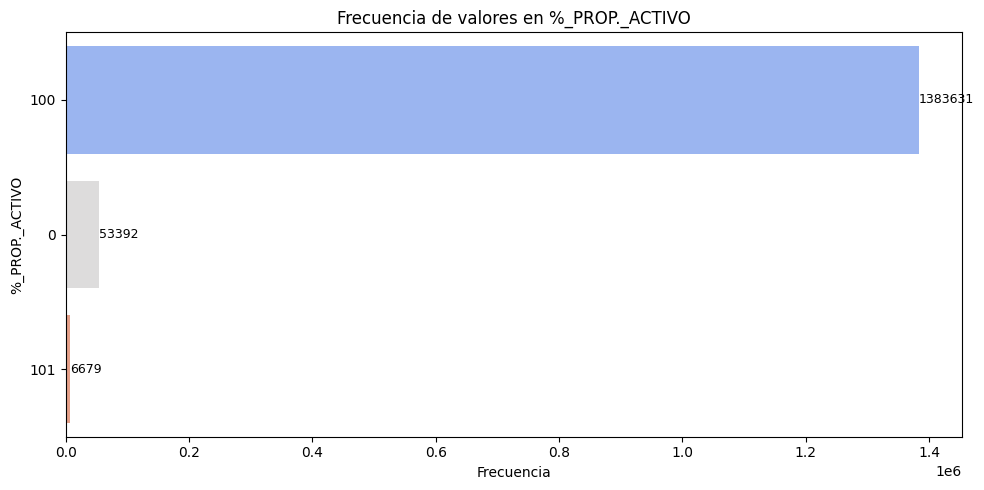

C:\Users\madelgado\AppData\Local\Temp\ipykernel_25508\1256154882.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='coolwarm')


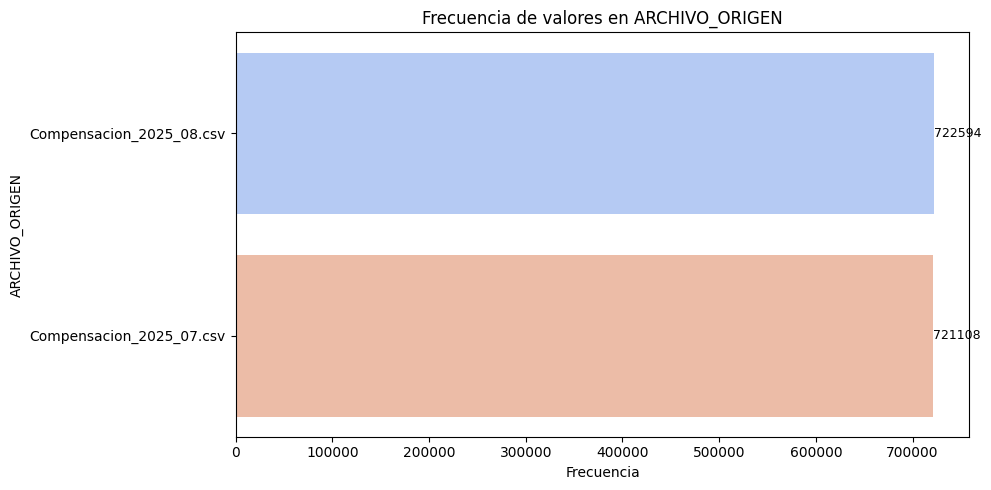

In [117]:
def explorar_indicadores(df):
    print("=== EXPLORACIÓN DE LA BASE DE INDICADORES ===\n")

    # Columnas que deben tratarse como categóricas aunque sean numéricas
    cols_categoricas = [
        'GRUPO_CALIDAD', 'NIVEL_TENSION', '%_PROP._ACTIVO', 'ID_MERCADO', 
        'OPERADOR_RED', 'PERIODO'
    ]

    # Convertirlas a tipo string si existen
    for c in cols_categoricas:
        if c in df.columns:
            df[c] = df[c].astype(str)

    # Asegurar que NIU sea string
    if 'NIU' in df.columns:
        df['NIU'] = df['NIU'].astype(str).str.strip()

    # Seleccionar variables numéricas y categóricas
    numericas = df.select_dtypes(include=['number']).columns
    categoricas = df.select_dtypes(include=['object']).columns

    # Total de valores faltantes
    faltantes = df.isnull().sum().sum()
    print(f'Número de columnas numéricas reales: {len(numericas)}')
    print(f'Número de columnas categóricas: {len(categoricas)}')
    print(f'Total de valores faltantes: {faltantes}\n')

    # Estadísticas descriptivas de las variables numéricas
    if len(numericas) > 0:
        print("Estadísticas descriptivas de las variables numéricas:")
        print(df[numericas].describe().T)
    else:
        print("No hay variables numéricas continuas para describir.\n")

    # --- Visualizaciones principales ---
    if 'VALOR_COMPENSAR_FACTURA' in df.columns:
        plt.figure(figsize=(8, 5))
        sns.histplot(df['VALOR_COMPENSAR_FACTURA'].dropna(), bins=50, kde=True, color='teal')
        plt.title('Distribución del Valor de Compensación')
        plt.xlabel('Valor Compensar en Factura ($)')
        plt.ylabel('Frecuencia')
        plt.tight_layout()
        plt.show()

    if 'DIU' in df.columns and 'VALOR_COMPENSAR_FACTURA' in df.columns:
        plt.figure(figsize=(7, 5))
        sns.scatterplot(x='DIU', y='VALOR_COMPENSAR_FACTURA', data=df, alpha=0.5)
        plt.title('Duración de Interrupciones (DIU) vs Valor Compensado')
        plt.xlabel('DIU (horas)')
        plt.ylabel('Valor Compensado ($)')
        plt.tight_layout()
        plt.show()

    if len(numericas) > 0:
        df[numericas].hist(bins=20, figsize=(14, 10), color='skyblue', edgecolor='black')
        plt.suptitle('Histogramas de Variables Numéricas - Indicadores', fontsize=16)
        plt.tight_layout()
        plt.show()

    # --- Gráficos automáticos para variables categóricas ---
    print("\nGenerando gráficos de frecuencia para las variables categóricas...")
    for col in categoricas:
        if df[col].nunique() > 1 and df[col].nunique() <= 30:
            plt.figure(figsize=(10, 5))
            ax = sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='coolwarm')
            plt.title(f'Frecuencia de valores en {col}')
            plt.xlabel('Frecuencia')
            plt.ylabel(col)
            for p in ax.patches:
                ancho = p.get_width()
                ax.annotate(f'{int(ancho)}', (ancho + 0.5, p.get_y() + p.get_height()/2),
                            ha='left', va='center', fontsize=9, color='black')
            plt.tight_layout()
            plt.show()

explorar_indicadores(indicadores)

In [118]:
indicadores['VALOR_COMPENSAR_FACTURA'].unique()

array([    0.   , 16874.   ,  8315.895, ...,  4070.708, 26525.239,
        9907.644])

=== EXPLORACIÓN DE LA BASE DE CLIENTES ===

Número de columnas numéricas reales: 1
Número de columnas categóricas: 33
Total de valores faltantes: 4401948

Estadísticas descriptivas de las variables numéricas reales:
                count       mean         std   min  25%   50%   75%     max
CAPAC_AUTOGEN  2671.0  49.239105  203.125178  0.01  5.0  12.0  99.5  6042.0


C:\Users\madelgado\AppData\Local\Temp\ipykernel_25508\1445317604.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='NIVEL_TENSION', data=df, palette='viridis')


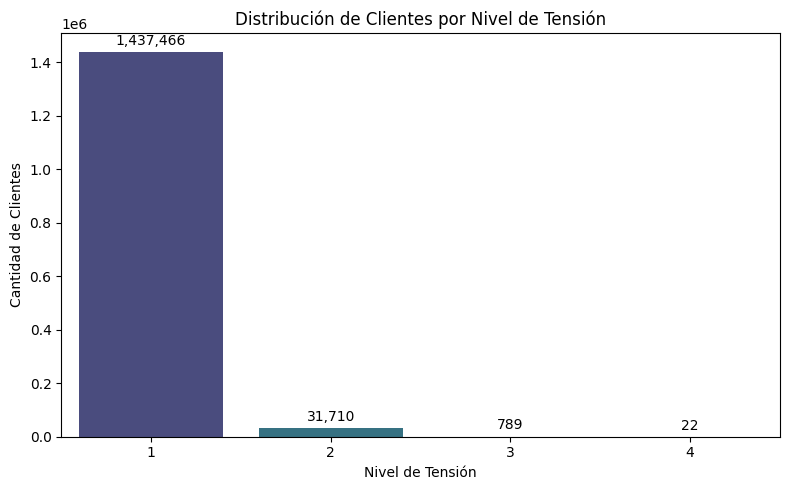

C:\Users\madelgado\AppData\Local\Temp\ipykernel_25508\1445317604.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='TIPO_CONEXION', data=df, palette='Set2')


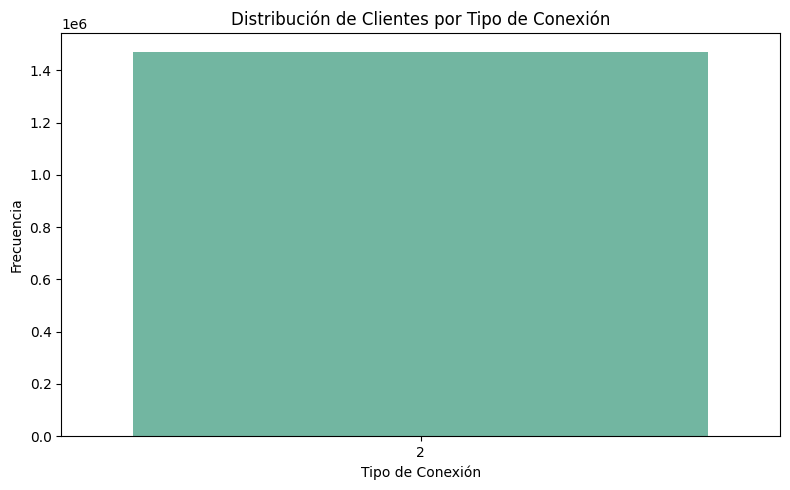

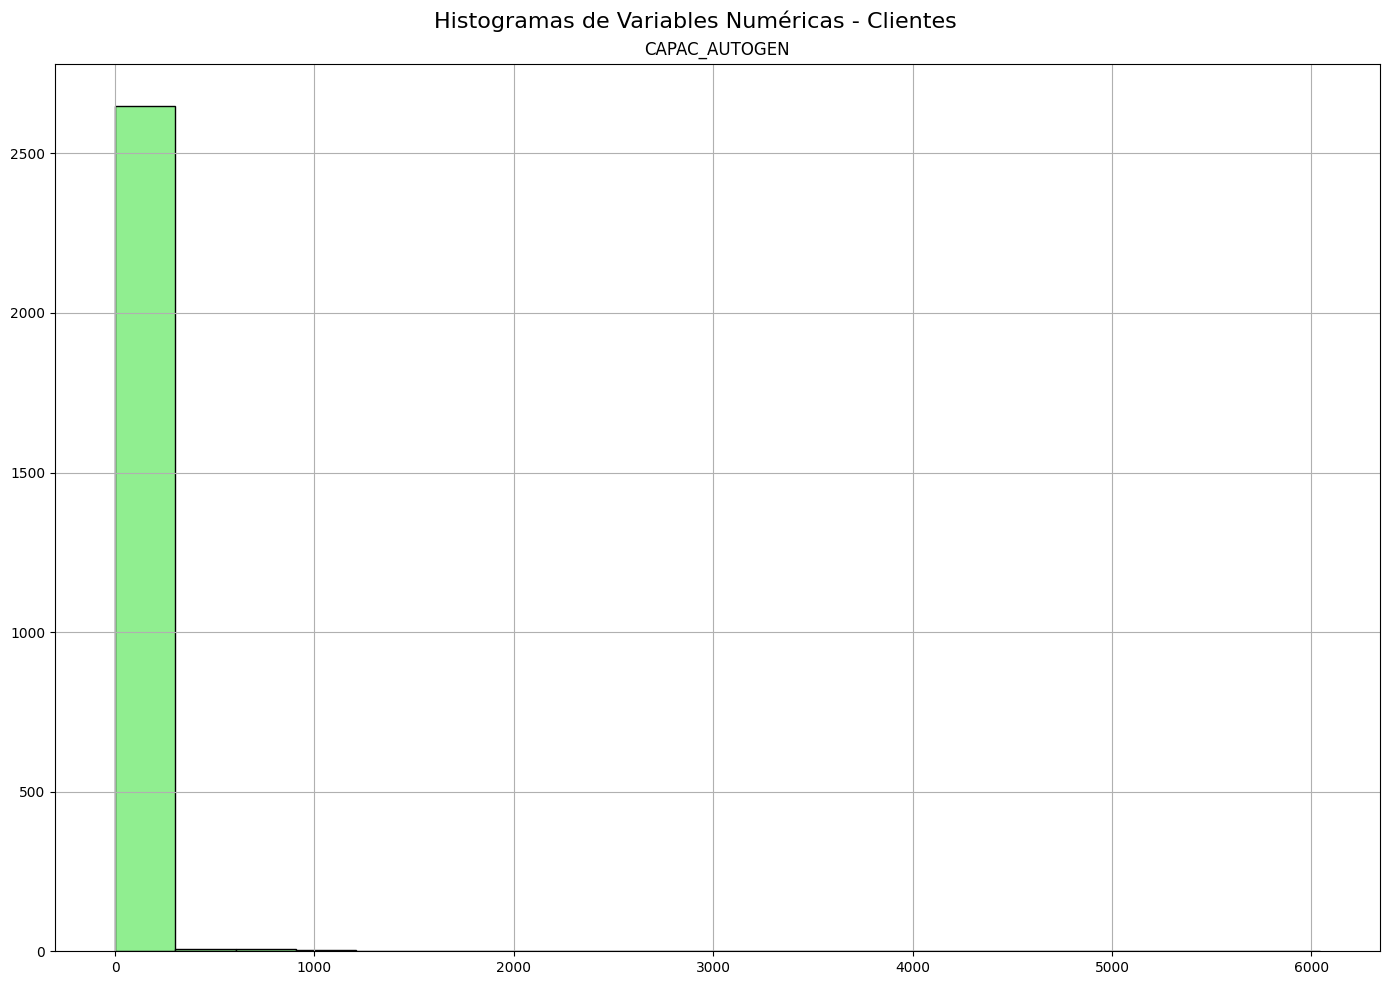


Generando gráficos de frecuencia para las variables categóricas...


C:\Users\madelgado\AppData\Local\Temp\ipykernel_25508\1445317604.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='coolwarm')


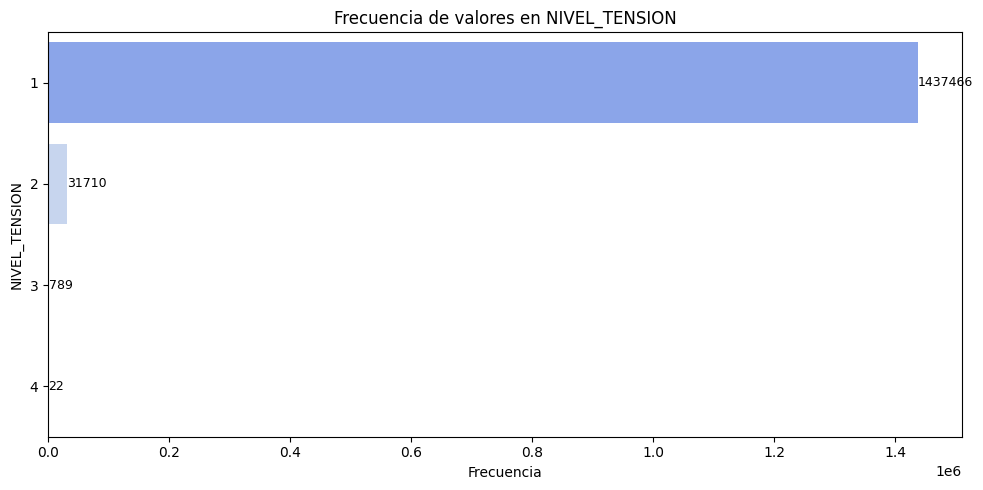

C:\Users\madelgado\AppData\Local\Temp\ipykernel_25508\1445317604.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='coolwarm')


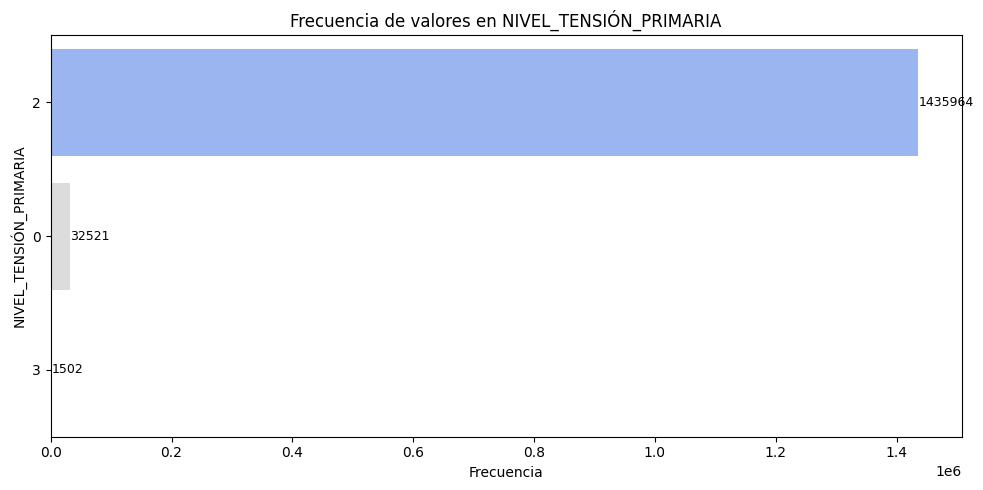

C:\Users\madelgado\AppData\Local\Temp\ipykernel_25508\1445317604.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='coolwarm')


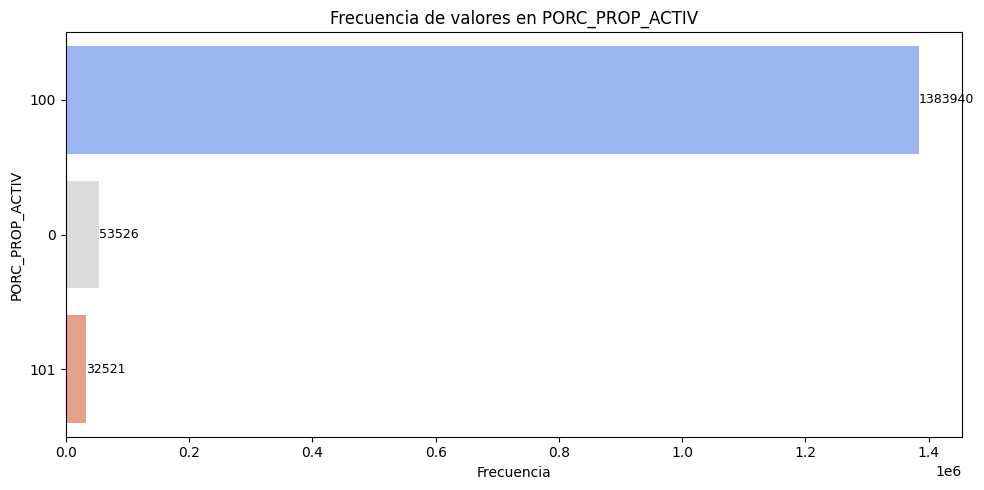

C:\Users\madelgado\AppData\Local\Temp\ipykernel_25508\1445317604.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='coolwarm')


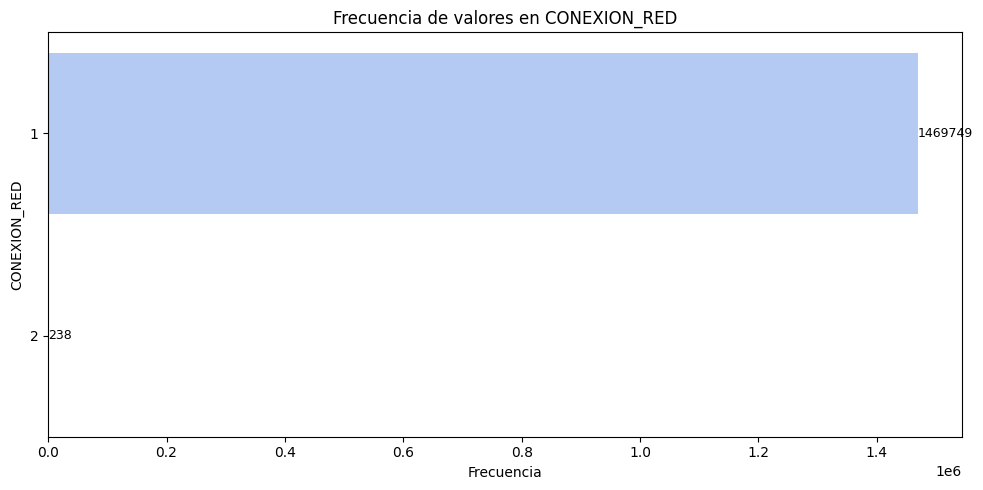

C:\Users\madelgado\AppData\Local\Temp\ipykernel_25508\1445317604.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='coolwarm')


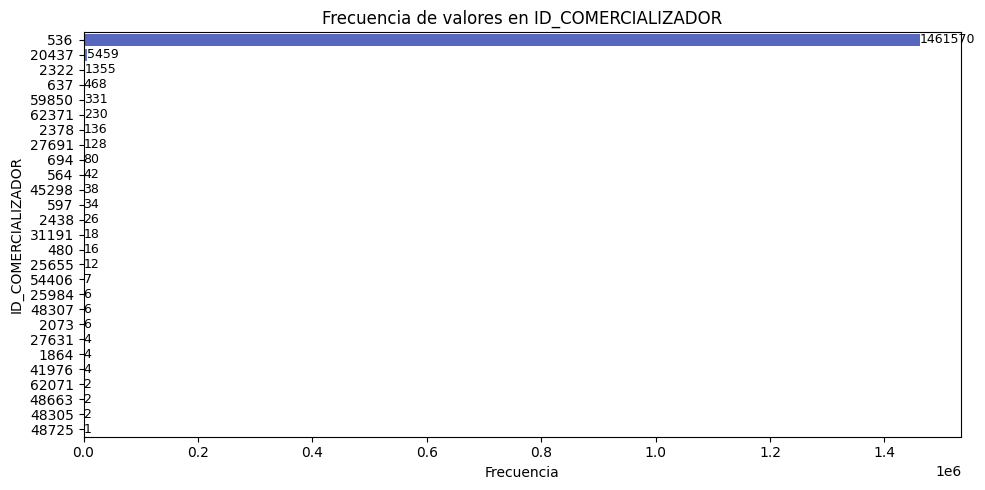

C:\Users\madelgado\AppData\Local\Temp\ipykernel_25508\1445317604.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='coolwarm')


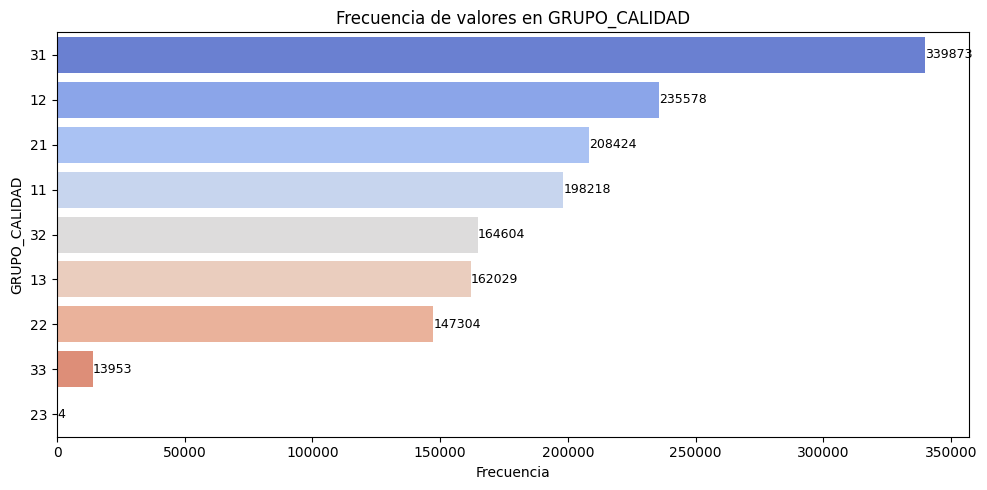

C:\Users\madelgado\AppData\Local\Temp\ipykernel_25508\1445317604.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='coolwarm')


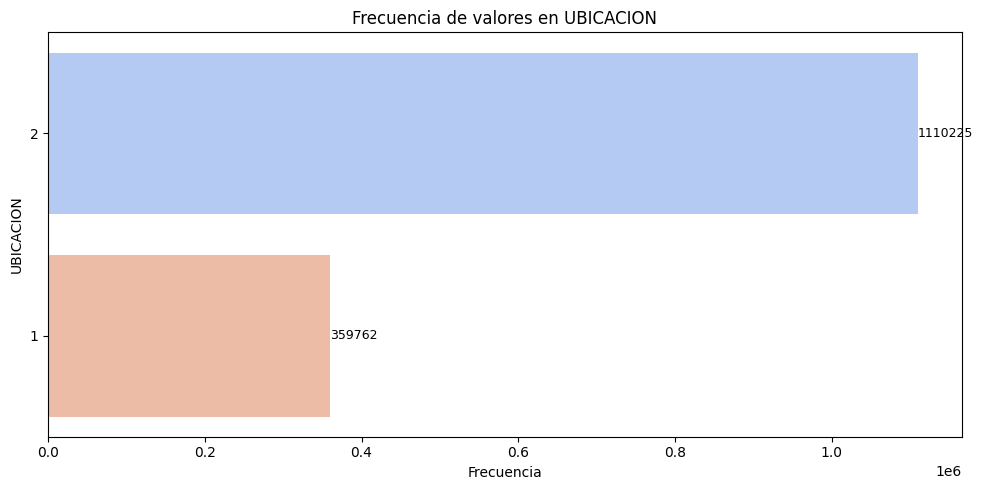

C:\Users\madelgado\AppData\Local\Temp\ipykernel_25508\1445317604.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='coolwarm')


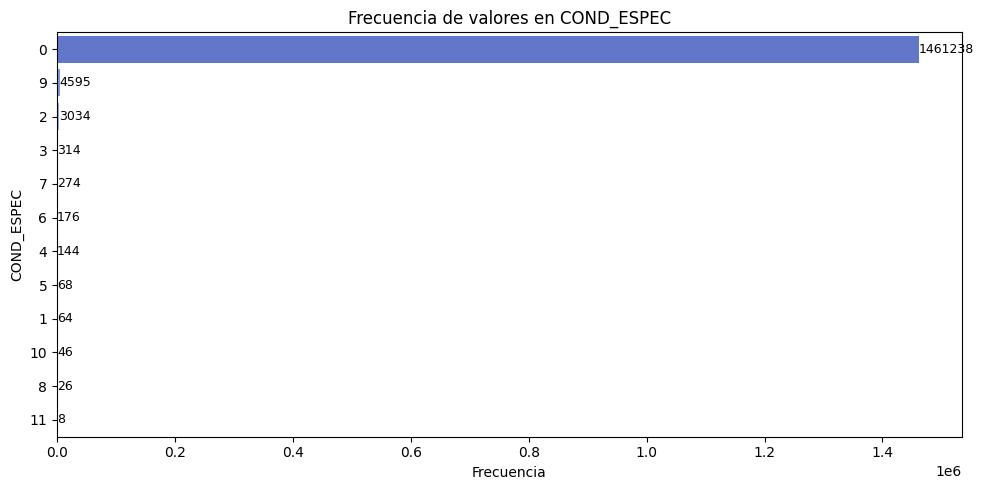

C:\Users\madelgado\AppData\Local\Temp\ipykernel_25508\1445317604.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='coolwarm')


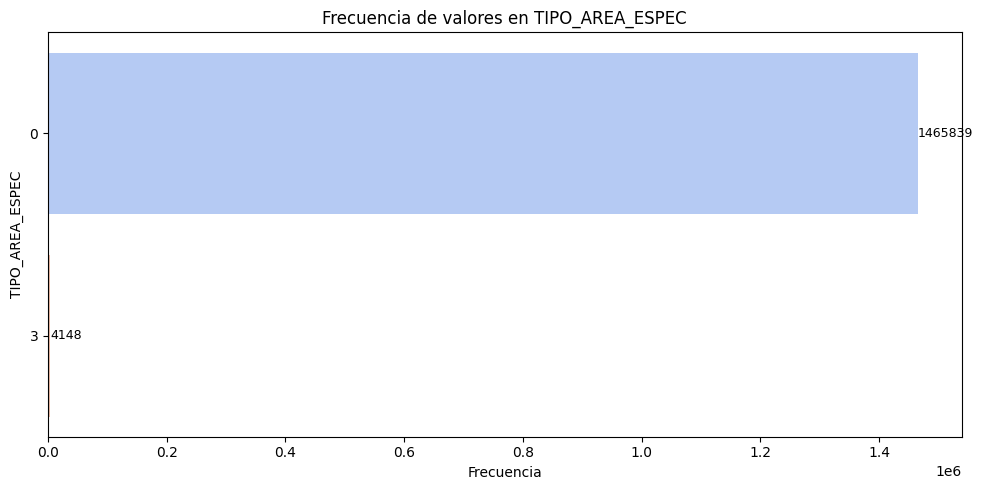

C:\Users\madelgado\AppData\Local\Temp\ipykernel_25508\1445317604.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='coolwarm')


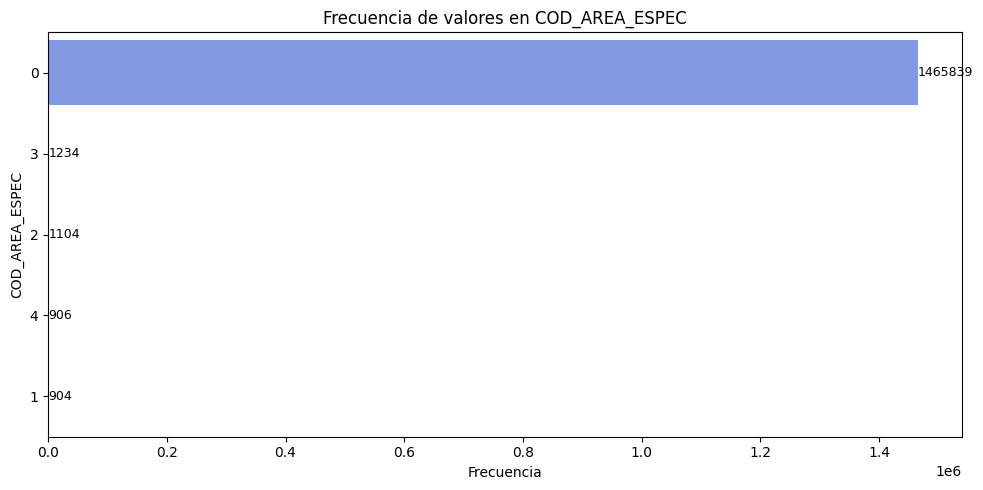

C:\Users\madelgado\AppData\Local\Temp\ipykernel_25508\1445317604.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='coolwarm')


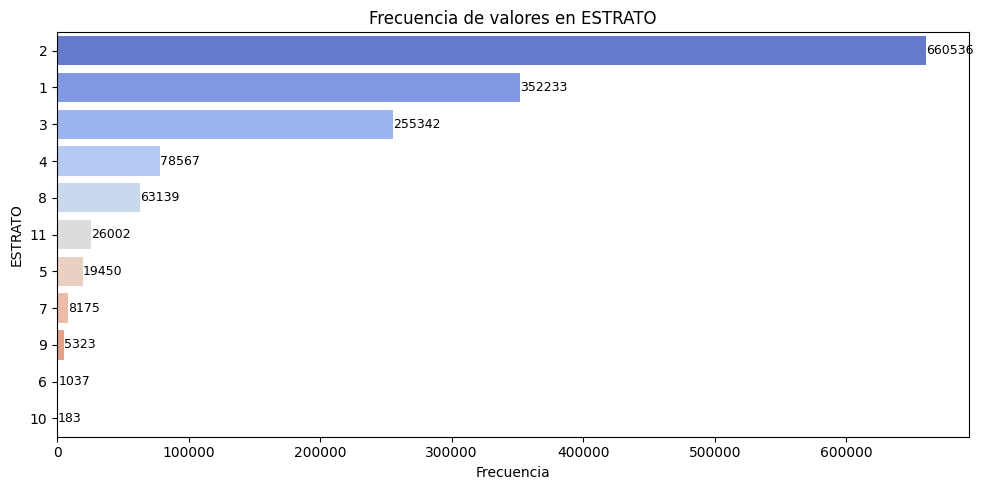

C:\Users\madelgado\AppData\Local\Temp\ipykernel_25508\1445317604.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='coolwarm')


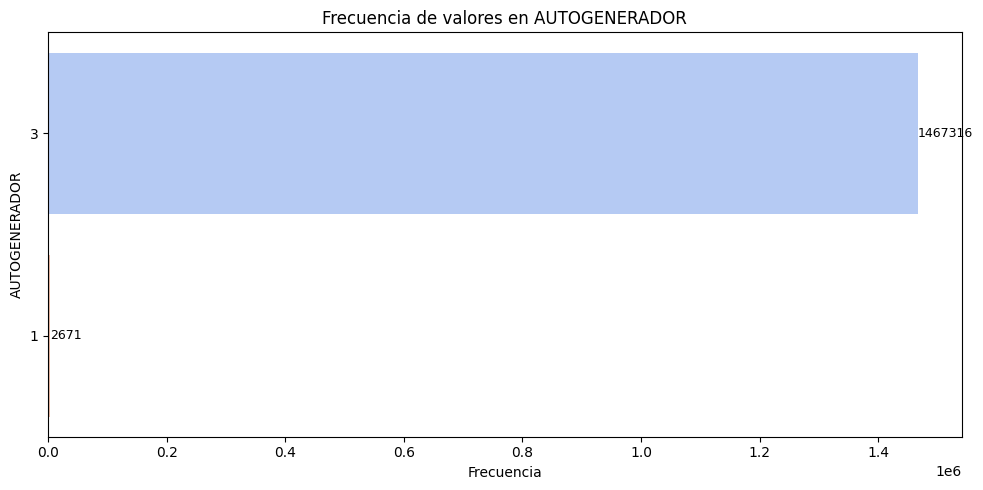

C:\Users\madelgado\AppData\Local\Temp\ipykernel_25508\1445317604.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='coolwarm')


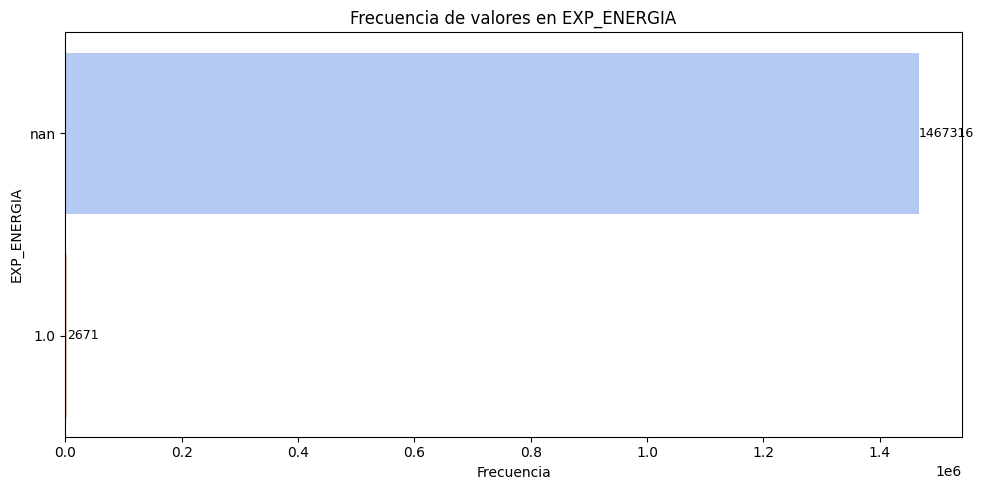

C:\Users\madelgado\AppData\Local\Temp\ipykernel_25508\1445317604.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='coolwarm')


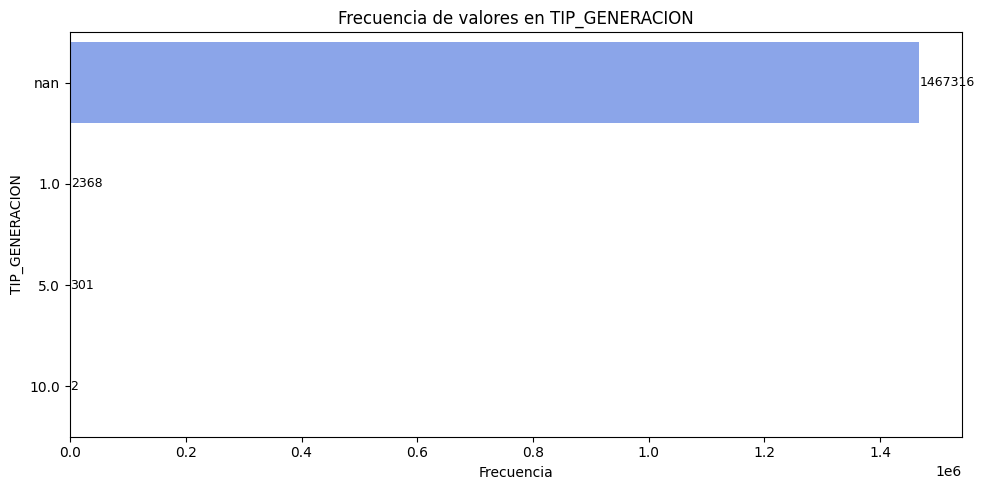

C:\Users\madelgado\AppData\Local\Temp\ipykernel_25508\1445317604.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='coolwarm')


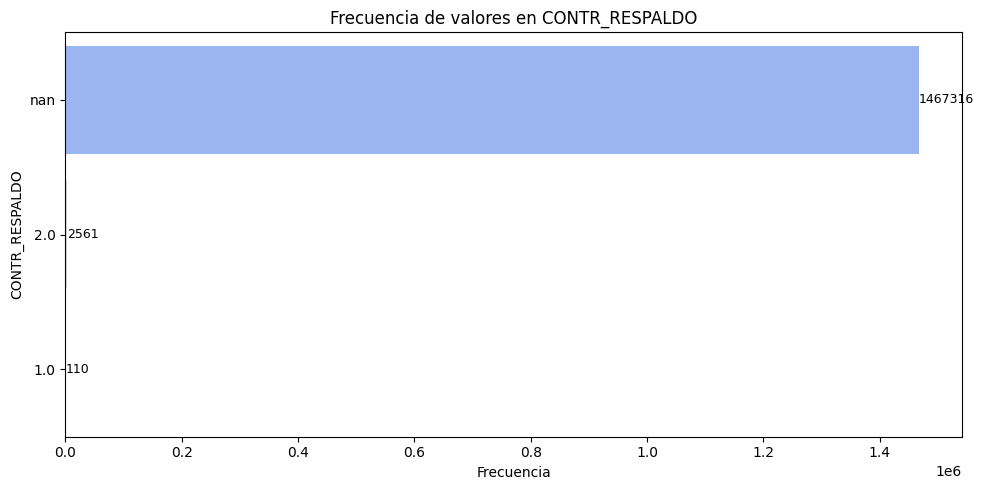

C:\Users\madelgado\AppData\Local\Temp\ipykernel_25508\1445317604.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='coolwarm')


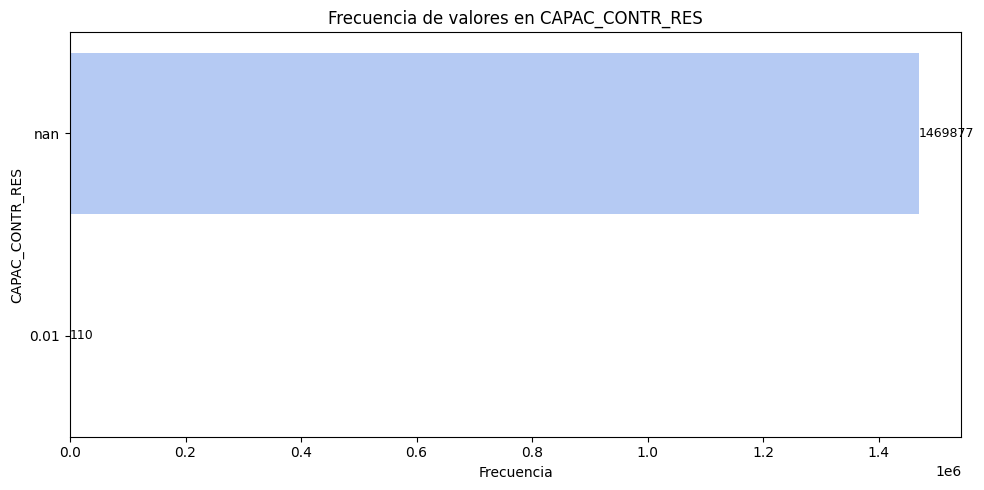

C:\Users\madelgado\AppData\Local\Temp\ipykernel_25508\1445317604.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='coolwarm')


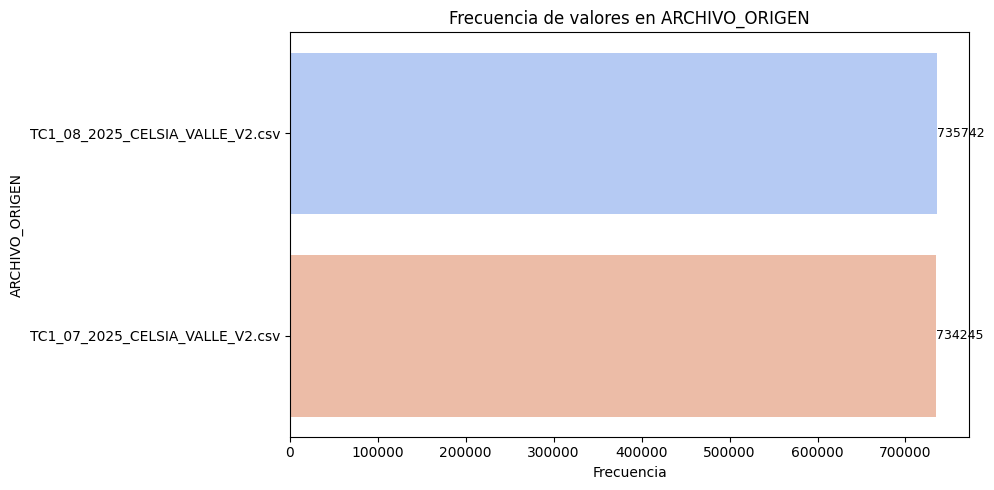

C:\Users\madelgado\AppData\Local\Temp\ipykernel_25508\1445317604.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='coolwarm')


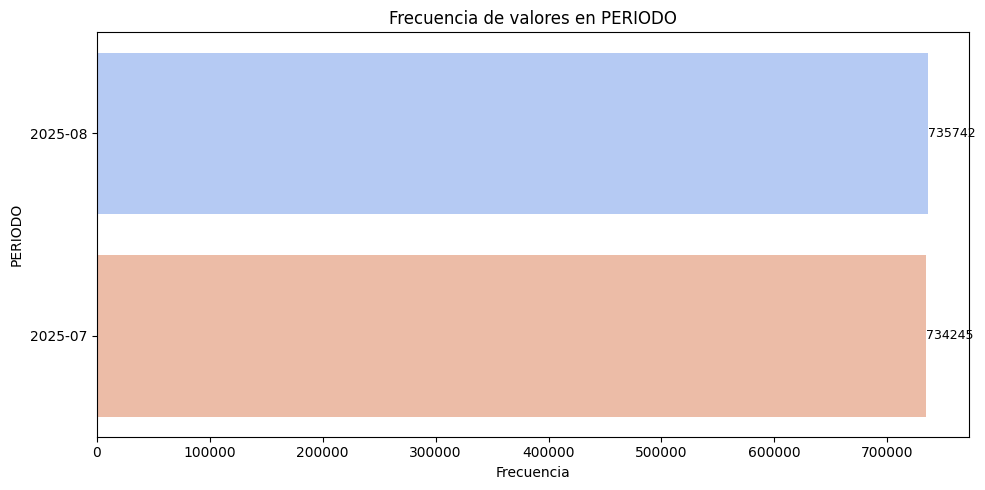

In [119]:
def explorar_clientes(df):
    print("=== EXPLORACIÓN DE LA BASE DE CLIENTES ===\n")

    # Columnas que deben tratarse como categóricas aunque sean numéricas
    cols_categoricas = [
        'TIPO_CONEXION', 'NIVEL_TENSION', 'NIVEL_TENSIÓN_PRIMARIA', 'PORC_PROP_ACTIV',
        'CONEXION_RED', 'ID_COMERCIALIZADOR', 'ID_MERCADO', 'GRUPO_CALIDAD',
        'COD_CIRCUITO_LINEA', 'COD_DANE', 'UBICACION', 'COND_ESPEC', 'TIPO_AREA_ESPEC',
        'COD_AREA_ESPEC', 'ESTRATO', 'ALTITUD', 'LONGITUD', 'LATITUD',
        'AUTOGENERADOR', 'EXP_ENERGIA', 'TIP_GENERACION', 'CONTR_RESPALDO', 'CAPAC_CONTR_RES'
    ]

    # Convertirlas a tipo string si existen
    for c in cols_categoricas:
        if c in df.columns:
            df[c] = df[c].astype(str)

    # Excluir las variables geográficas de las estadísticas
    excluir = ['LATITUD', 'LONGITUD', 'ALTITUD', 'ALTITUD_REAL']  # si existe

    numericas = df.select_dtypes(include=['number']).columns
    numericas = [col for col in numericas if col not in excluir]
    categoricas = df.select_dtypes(include=['object']).columns

    # Valores faltantes
    faltantes = df.isnull().sum().sum()
    print(f'Número de columnas numéricas reales: {len(numericas)}')
    print(f'Número de columnas categóricas: {len(categoricas)}')
    print(f'Total de valores faltantes: {faltantes}\n')

    # Estadísticas descriptivas
    if len(numericas) > 0:
        print("Estadísticas descriptivas de las variables numéricas reales:")
        print(df[numericas].describe().T)
    else:
        print("No hay variables numéricas continuas para describir.\n")

    # --- Visualizaciones principales ---
    if 'NIVEL_TENSION' in df.columns:
        plt.figure(figsize=(8, 5))
        ax = sns.countplot(x='NIVEL_TENSION', data=df, palette='viridis')
        plt.title('Distribución de Clientes por Nivel de Tensión')
        plt.xlabel('Nivel de Tensión')
        plt.ylabel('Cantidad de Clientes')
        for p in ax.patches:
            ax.annotate(f'{p.get_height():,.0f}', 
                        (p.get_x() + p.get_width() / 2., p.get_height()), 
                        ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 3),
                        textcoords='offset points')
        plt.tight_layout()
        plt.show()

    if 'TIPO_CONEXION' in df.columns:
        plt.figure(figsize=(8, 5))
        sns.countplot(x='TIPO_CONEXION', data=df, palette='Set2')
        plt.title('Distribución de Clientes por Tipo de Conexión')
        plt.xlabel('Tipo de Conexión')
        plt.ylabel('Frecuencia')
        plt.tight_layout()
        plt.show()

    # Histogramas de variables numéricas
    if len(numericas) > 0:
        df[numericas].hist(bins=20, figsize=(14, 10), color='lightgreen', edgecolor='black')
        plt.suptitle('Histogramas de Variables Numéricas - Clientes', fontsize=16)
        plt.tight_layout()
        plt.show()

    # --- NUEVO BLOQUE: Gráficos automáticos para todas las categóricas ---
    print("\nGenerando gráficos de frecuencia para las variables categóricas...")
    for col in categoricas:
        # Solo graficar si el número de categorías es razonable (<30)
        if df[col].nunique() > 1 and df[col].nunique() <= 30:
            plt.figure(figsize=(10, 5))
            ax = sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='coolwarm')
            plt.title(f'Frecuencia de valores en {col}')
            plt.xlabel('Frecuencia')
            plt.ylabel(col)
            for p in ax.patches:
                ancho = p.get_width()
                ax.annotate(f'{int(ancho)}', (ancho + 0.5, p.get_y() + p.get_height()/2),
                            ha='left', va='center', fontsize=9, color='black')
            plt.tight_layout()
            plt.show()

explorar_clientes(clientes)

### Limpieza de bases de datos

In [150]:
# Valores faltantes en la base de clientes
faltantes_clientes = (
    clientes.isnull().sum()
    .reset_index()
    .rename(columns={'index': 'Columna', 0: 'Valores_Faltantes'})
)
faltantes_clientes

,Columna,Valores_Faltantes
0,NIU,0
1,CODIGO_CONEXION,0
2,TIPO_CONEXION,0
3,NIVEL_TENSION,0
4,NIVEL_TENSIÓN_PRIMARIA,0
5,PORC_PROP_ACTIV,0
6,CONEXION_RED,0
7,ID_COMERCIALIZADOR,0
8,ID_MERCADO,0
9,GRUPO_CALIDAD,0


In [121]:
# Columnas con valores faltantes masivos (relacionadas con autogeneración)
cols_a_eliminar = [
    "EXP_ENERGIA",
    "CAPAC_AUTOGEN",
    "TIP_GENERACION",
    "COD_FRONTERA_EXPORT",
    "F_ENTRADA_GENERAR",
    "CONTR_RESPALDO",
    "CAPAC_CONTR_RES"
]

# Crear nueva base limpia
clientes_limpia = clientes.drop(columns=cols_a_eliminar).reset_index(drop=True)

# Confirmar resultados
print("=== Limpieza completada ===")
print(f"Filas totales: {len(clientes_limpia):,}")
print(f"Columnas antes: {clientes.shape[1]}  →  después: {clientes_limpia.shape[1]}")
print("Columnas eliminadas:", cols_a_eliminar)

=== Limpieza completada ===
Filas totales: 1,469,987
Columnas antes: 34  →  después: 27
Columnas eliminadas: ['EXP_ENERGIA', 'CAPAC_AUTOGEN', 'TIP_GENERACION', 'COD_FRONTERA_EXPORT', 'F_ENTRADA_GENERAR', 'CONTR_RESPALDO', 'CAPAC_CONTR_RES']


In [122]:
cols_a_verificar = [
    "EXP_ENERGIA", "CAPAC_AUTOGEN", "TIP_GENERACION",
    "COD_FRONTERA_EXPORT", "F_ENTRADA_GENERAR",
    "CONTR_RESPALDO", "CAPAC_CONTR_RES"
]

clientes_sin_nulos = clientes.dropna(subset=cols_a_verificar).reset_index(drop=True)

print(f"Filas originales: {len(clientes):,}")
print(f"Filas después de eliminar nulos en columnas seleccionadas: {len(clientes_sin_nulos):,}")

Filas originales: 1,469,987
Filas después de eliminar nulos en columnas seleccionadas: 2,671


#### Unión clientes vs indicadores

Dado que un cliente puede aparecer más de una vez en el df de clientes, sin embargo este aparecerá una sola vez en el de indicadores, se toma como referencia el df de indicadores y se hace el merge con clientes, pero dejando la info solo del primer registro. 

Este ajuste se hace dado que un cliente puede cambiar de comercializador en un mes y cuando esto pasa se registra dos veces en el df clientes, sin embargo sus indicadores siguen siendo los mismos. 

In [123]:
# --- Eliminar duplicados en clientes por NIU y PERIODO ---
clientes_dedup = clientes.drop_duplicates(subset=['NIU', 'PERIODO'], keep='first')

print(f"Clientes originales: {len(clientes):,}")
print(f"Clientes sin duplicados (NIU + PERIODO): {len(clientes_dedup):,}")

# --- Merge: base principal = indicadores ---
df_merged = pd.merge(
    indicadores,
    clientes_dedup,
    how='left',  # mantiene todos los registros de indicadores
    on=['NIU', 'PERIODO'],
    suffixes=('_x', '_y')
)

# --- Validaciones ---
print(f"\nRegistros en indicadores: {len(indicadores):,}")
print(f"Registros en df_merged:   {len(df_merged):,}")
print(f"Diferencia:               {len(indicadores) - len(df_merged)}")

# Comprobar duplicados en la base final
duplicados = df_merged.duplicated(subset=['NIU', 'PERIODO']).sum()
print(f"Duplicados por NIU y PERIODO en df_merged: {duplicados}")

# Distribución de periodos para verificar consistencia
print("\nConteo por PERIODO:")
print(df_merged['PERIODO'].value_counts().sort_index())

# Vista previa
df_merged.head(5)


Clientes originales: 1,469,987
Clientes sin duplicados (NIU + PERIODO): 1,469,614

Registros en indicadores: 1,443,702
Registros en df_merged:   1,443,702
Diferencia:               0
Duplicados por NIU y PERIODO en df_merged: 0

Conteo por PERIODO:
PERIODO
2025-07    721108
2025-08    722594
Name: count, dtype: int64


,ERROR_EN_METAS,OPERADOR_RED,PERIODO,NIU,DIU,DIUM,FIU,FIUM,HC,DIUG,...,AUTOGENERADOR,EXP_ENERGIA,CAPAC_AUTOGEN,TIP_GENERACION,COD_FRONTERA_EXPORT,F_ENTRADA_GENERAR,CONTR_RESPALDO,CAPAC_CONTR_RES,ARCHIVO_ORIGEN_y,TIPO_BASE_y
0,NO,CELSIA VALLE,2025-07,1000001,0.00000,0.0,0,0,0.0,10.25,...,3,nan,NaN,nan,NaN,NaN,nan,nan,TC1_07_2025_CELSIA_VALLE_V2.csv,clientes
1,NO,CELSIA VALLE,2025-07,1000005,13.29471,0.0,4,0,0.0,57.02,...,3,nan,NaN,nan,NaN,NaN,nan,nan,TC1_07_2025_CELSIA_VALLE_V2.csv,clientes
2,NO,CELSIA VALLE,2025-07,1000008,13.29471,0.0,4,0,0.0,57.02,...,3,nan,NaN,nan,NaN,NaN,nan,nan,TC1_07_2025_CELSIA_VALLE_V2.csv,clientes
3,NO,CELSIA VALLE,2025-07,1000009,13.29471,0.0,4,0,0.0,57.02,...,3,nan,NaN,nan,NaN,NaN,nan,nan,TC1_07_2025_CELSIA_VALLE_V2.csv,clientes
4,NO,CELSIA VALLE,2025-07,1000011,13.29471,0.0,4,0,0.0,57.02,...,3,nan,NaN,nan,NaN,NaN,nan,nan,TC1_07_2025_CELSIA_VALLE_V2.csv,clientes


In [124]:
# Valores faltantes en la base de base_merged
faltantes_base_merged = (
    df_merged.isnull().sum()
    .reset_index()
    .rename(columns={'index': 'Columna', 0: 'Valores_Faltantes'})
)
faltantes_base_merged

,Columna,Valores_Faltantes
0,ERROR_EN_METAS,0
1,OPERADOR_RED,0
2,PERIODO,0
3,NIU,0
4,DIU,0
...,...,...
57,F_ENTRADA_GENERAR,1441045
58,CONTR_RESPALDO,20
59,CAPAC_CONTR_RES,20
60,ARCHIVO_ORIGEN_y,20


In [125]:
base_merged_sin_nulos = df_merged.dropna().reset_index(drop=True)

# Confirmar resultados
print("=== Limpieza completada ===")
print(f"Filas originales: {len(df_merged):,}")
print(f"Filas después de eliminar nulos: {len(base_merged_sin_nulos):,}")
print(f"Filas eliminadas: {len(df_merged) - len(base_merged_sin_nulos):,}")

=== Limpieza completada ===
Filas originales: 1,443,702
Filas después de eliminar nulos: 2,657
Filas eliminadas: 1,441,045


In [126]:
base_merged_sin_nulos

,ERROR_EN_METAS,OPERADOR_RED,PERIODO,NIU,DIU,DIUM,FIU,FIUM,HC,DIUG,...,AUTOGENERADOR,EXP_ENERGIA,CAPAC_AUTOGEN,TIP_GENERACION,COD_FRONTERA_EXPORT,F_ENTRADA_GENERAR,CONTR_RESPALDO,CAPAC_CONTR_RES,ARCHIVO_ORIGEN_y,TIPO_BASE_y
0,NO,CELSIA VALLE,2025-07,1002387,8.36415,4.00944,4,1,0.0,57.02,...,1,1.0,1.0,1.0,AGPE0001,31-10-2023,2.0,nan,TC1_07_2025_CELSIA_VALLE_V2.csv,clientes
1,NO,CELSIA VALLE,2025-07,1003717,131.16489,0.00000,38,0,0.0,57.02,...,1,1.0,15.0,1.0,AGPE0001,26-07-2024,2.0,nan,TC1_07_2025_CELSIA_VALLE_V2.csv,clientes
2,NO,CELSIA VALLE,2025-07,1003849,6.18693,0.00000,5,0,0.0,10.25,...,1,1.0,1000.0,1.0,AGPE0001,28-06-2024,2.0,nan,TC1_07_2025_CELSIA_VALLE_V2.csv,clientes
3,NO,CELSIA VALLE,2025-07,1003933,8.63664,0.00000,7,0,0.0,57.02,...,1,1.0,10.0,1.0,AGPE0001,01-07-2025,2.0,nan,TC1_07_2025_CELSIA_VALLE_V2.csv,clientes
4,NO,CELSIA VALLE,2025-07,1003943,29.29856,0.00000,13,0,0.0,57.02,...,1,1.0,1.0,1.0,AGPE0001,31-12-2023,2.0,nan,TC1_07_2025_CELSIA_VALLE_V2.csv,clientes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2652,NO,CELSIA VALLE,2025-08,4193511,3.58000,0.13472,4,1,0.0,57.02,...,1,1.0,4.0,1.0,AGPE0001,17-12-2024,2.0,nan,TC1_08_2025_CELSIA_VALLE_V2.csv,clientes
2653,NO,CELSIA VALLE,2025-08,4193639,18.48000,0.06083,15,1,0.0,40.96,...,1,1.0,100.0,1.0,AGPE0001,25-04-2024,2.0,nan,TC1_08_2025_CELSIA_VALLE_V2.csv,clientes
2654,NO,CELSIA VALLE,2025-08,4194625,14.03000,10.72333,26,4,0.0,40.96,...,1,1.0,12.0,1.0,AGPE0001,01-06-2025,2.0,nan,TC1_08_2025_CELSIA_VALLE_V2.csv,clientes
2655,NO,CELSIA VALLE,2025-08,4195296,44.20000,0.00000,16,0,0.0,40.96,...,1,1.0,10.0,1.0,AGPE0001,01-07-2025,2.0,nan,TC1_08_2025_CELSIA_VALLE_V2.csv,clientes


In [127]:

base_final = base_merged_sin_nulos.drop(columns=["OPERADOR_RED", "ARCHIVO_ORIGEN_y", "TIPO_BASE_y"]).reset_index(drop=True)

In [128]:
# Identificar columnas que tienen pares _x y _y
cols_x = [c for c in base_final.columns if c.endswith("_x")]
cols_y = [c for c in base_final.columns if c.endswith("_y")]

# Quitar columnas ya eliminadas si existían
cols_x = [c for c in cols_x if c.replace("_x", "_y") in cols_y]

comparacion_resultados = []

for col_x in cols_x:
    col_y = col_x.replace("_x", "_y")

    iguales = (base_final[col_x] == base_final[col_y]).sum()
    total = len(base_final)
    porcentaje_iguales = round(iguales / total * 100, 4)
    distintos = total - iguales

    comparacion_resultados.append({
        "Columna_X": col_x,
        "Columna_Y": col_y,
        "Coincidencias": iguales,
        "Diferencias": distintos,
        "Coincidencia_%": porcentaje_iguales
    })

comparacion_df = pd.DataFrame(comparacion_resultados)
print("=== Comparación entre columnas _x y _y ===")
print(comparacion_df)

=== Comparación entre columnas _x y _y ===
         Columna_X        Columna_Y  Coincidencias  Diferencias  \
0  GRUPO_CALIDAD_x  GRUPO_CALIDAD_y           2657            0   
1  NIVEL_TENSION_x  NIVEL_TENSION_y           2657            0   
2     ID_MERCADO_x     ID_MERCADO_y           2657            0   

   Coincidencia_%  
0           100.0  
1           100.0  
2           100.0  


In [129]:
# Identificar columnas que terminan en _y
cols_y = [col for col in base_final.columns if col.endswith("_y")]

# Eliminar esas columnas
base_final_limpia = base_final.drop(columns=cols_y).reset_index(drop=True)

# Confirmar resultado
print("=== Columnas eliminadas correctamente ===")
print(f"Columnas eliminadas: {cols_y}")
print(f"Columnas finales: {len(base_final_limpia.columns)}")

=== Columnas eliminadas correctamente ===
Columnas eliminadas: ['NIVEL_TENSION_y', 'ID_MERCADO_y', 'GRUPO_CALIDAD_y']
Columnas finales: 56


In [130]:
base_final_limpia.columns

Index(['ERROR_EN_METAS', 'PERIODO', 'NIU', 'DIU', 'DIUM', 'FIU', 'FIUM', 'HC',
       'DIUG', 'FIUG', 'VC', 'TVC', 'THC', 'COMPENSA_DIU', 'COMPENSA_FIU',
       'CEC', 'VCD', 'VCF', 'VALOR_COMPENSAR_FACTURA', 'GRUPO_CALIDAD_x',
       'NIVEL_TENSION_x', 'CARGO_DISTRIBUCION', 'CONSUMO_MES',
       'MES_FACTURADOS', 'DURA._INTERRUPCIONES', '%_PROP._ACTIVO',
       'ID_MERCADO_x', 'ARCHIVO_ORIGEN_x', 'TIPO_BASE_x', 'CODIGO_CONEXION',
       'TIPO_CONEXION', 'NIVEL_TENSIÓN_PRIMARIA', 'PORC_PROP_ACTIV',
       'CONEXION_RED', 'ID_COMERCIALIZADOR', 'COD_FRONTERA_COMERCIAL',
       'COD_CIRCUITO_LINEA', 'COD_TRANSFORMADOR', 'COD_DANE', 'UBICACION',
       'DIRECCION', 'COND_ESPEC', 'TIPO_AREA_ESPEC', 'COD_AREA_ESPEC',
       'ESTRATO', 'ALTITUD', 'LONGITUD', 'LATITUD', 'AUTOGENERADOR',
       'EXP_ENERGIA', 'CAPAC_AUTOGEN', 'TIP_GENERACION', 'COD_FRONTERA_EXPORT',
       'F_ENTRADA_GENERAR', 'CONTR_RESPALDO', 'CAPAC_CONTR_RES'],
      dtype='object')

In [131]:
# Variables de compensación
vars_compensacion = ['COMPENSA_DIU', 'COMPENSA_FIU', 'VALOR_COMPENSAR_FACTURA']

# Mostrar las primeras filas
print("=== Primeros registros de las variables de compensación ===")
print(base_final_limpia[vars_compensacion].head(20))

=== Primeros registros de las variables de compensación ===
   COMPENSA_DIU COMPENSA_FIU  VALOR_COMPENSAR_FACTURA
0            NO           NO                      0.0
1            NO           NO                      0.0
2            NO           NO                      0.0
3            NO           NO                      0.0
4            NO           NO                      0.0
5            NO           NO                      0.0
6            NO           NO                      0.0
7            NO           NO                      0.0
8            NO           NO                      0.0
9            NO           NO                      0.0
10           NO           NO                      0.0
11           NO           NO                      0.0
12           SI           SI                      0.0
13           NO           NO                      0.0
14           NO           NO                      0.0
15           NO           NO                      0.0
16           NO       

In [132]:
base_final_limpia["COMPENSADO"] = (
    (base_final_limpia["COMPENSA_DIU"] == 'SI') | 
    (base_final_limpia["COMPENSA_FIU"] == 'SI')
).astype(int)

In [133]:
base_final_limpia["COMPENSADO"].unique()

array([0, 1])

In [134]:
base_final_limpia["COMPENSADO"].value_counts(normalize=True) * 100

COMPENSADO
0    85.923974
1    14.076026
Name: proportion, dtype: float64

In [135]:
from sklearn.utils import resample

# Separar clases
df_mayor = base_final_limpia[base_final_limpia.COMPENSADO == 0]
df_menor = base_final_limpia[base_final_limpia.COMPENSADO == 1]

# Submuestrear la clase mayoritaria
df_mayor_down = resample(df_mayor,
                         replace=True,
                         n_samples=len(df_menor)*2,  # relación 2:1
                         random_state=42)

# Combinar
base_balanceada = pd.concat([df_mayor_down, df_menor]).sample(frac=1, random_state=42).reset_index(drop=True)

# Confirmar
base_balanceada["COMPENSADO"].value_counts(normalize=True) * 100

COMPENSADO
0    66.666667
1    33.333333
Name: proportion, dtype: float64

In [136]:
base_balanceada

,ERROR_EN_METAS,PERIODO,NIU,DIU,DIUM,FIU,FIUM,HC,DIUG,FIUG,...,LATITUD,AUTOGENERADOR,EXP_ENERGIA,CAPAC_AUTOGEN,TIP_GENERACION,COD_FRONTERA_EXPORT,F_ENTRADA_GENERAR,CONTR_RESPALDO,CAPAC_CONTR_RES,COMPENSADO
0,NO,2025-08,2911993,20.36000,3.30833,17,2,1.67000,10.25,13,...,3.265303,1,1.0,6.0,1.0,AGPE0001,11-06-2024,2.0,nan,1
1,NO,2025-07,3819297,53.70438,0.00000,23,0,0.00438,40.96,23,...,3.51198,1,1.0,1.0,1.0,AGPE0001,31-12-2023,2.0,nan,1
2,NO,2025-07,3654186,0.24083,0.07666,3,1,0.00000,10.25,13,...,3.246897,1,1.0,1.0,1.0,AGPE0001,31-10-2023,2.0,nan,0
3,NO,2025-08,1115810,1.30000,0.00000,2,0,0.00000,40.96,23,...,3.647698,1,1.0,10.0,1.0,AGPE0001,02-05-2025,2.0,nan,0
4,NO,2025-08,3782854,14.93000,3.30833,16,2,0.00000,10.25,13,...,3.273328,1,1.0,3.0,1.0,AGPE0001,24-09-2024,2.0,nan,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1117,NO,2025-07,4177263,5.46638,0.00000,4,0,0.00000,40.96,23,...,3.596898,1,1.0,1.0,1.0,AGPE0001,31-10-2023,2.0,nan,0
1118,NO,2025-07,3356346,48.70855,1.86444,17,2,0.00000,57.02,26,...,3.256949,1,1.0,10.0,1.0,AGPE0001,01-07-2025,2.0,nan,0
1119,NO,2025-08,3544694,16.72000,3.30833,17,2,1.66000,10.25,13,...,3.26754,1,1.0,45.0,1.0,AGPE0001,31-10-2022,2.0,nan,1
1120,NO,2025-08,4025259,16.46000,3.30833,16,2,0.00000,10.25,13,...,3.274352,1,1.0,18.0,1.0,AGPE0001,25-09-2021,2.0,nan,1


In [137]:
# Lista de columnas a eliminar
cols_drop = [
    'ERROR_EN_METAS', 'OPERADOR_RED', 'ID_MERCADO_x',
    'ARCHIVO_ORIGEN_x', 'TIPO_BASE_x', 'CODIGO_CONEXION', 'TIPO_CONEXION',
    'ID_COMERCIALIZADOR', 'COD_FRONTERA_COMERCIAL', 'COD_CIRCUITO_LINEA',
    'COD_TRANSFORMADOR', 'COD_DANE', 'NIU', 'COD_AREA_ESPEC', 'DIRECCION', 'PORC_PROP_ACTIV',  'TVC', 'HC', 'DURA._INTERRUPCIONES','THC',
    'TIPO_AREA_ESPEC', 'ALTITUD', 'LONGITUD', 'LATITUD','COMPENSA_DIU', 'COMPENSA_FIU', 'FIU', 'FIUM', 'DIU', 'DIUM', 'VC',
]

# Eliminar duplicadas si se repiten en la lista
cols_drop = list(set(cols_drop))

# Crear nueva base sin esas columnas
base_balanceada_mod = base_balanceada.drop(columns=cols_drop, errors='ignore')

# Confirmar cambios
print("Columnas eliminadas:", len(cols_drop))
print("Columnas finales:", len(base_balanceada_mod.columns))
base_balanceada_mod.columns

Columnas eliminadas: 31
Columnas finales: 27


Index(['PERIODO', 'DIUG', 'FIUG', 'CEC', 'VCD', 'VCF',
       'VALOR_COMPENSAR_FACTURA', 'GRUPO_CALIDAD_x', 'NIVEL_TENSION_x',
       'CARGO_DISTRIBUCION', 'CONSUMO_MES', 'MES_FACTURADOS', '%_PROP._ACTIVO',
       'NIVEL_TENSIÓN_PRIMARIA', 'CONEXION_RED', 'UBICACION', 'COND_ESPEC',
       'ESTRATO', 'AUTOGENERADOR', 'EXP_ENERGIA', 'CAPAC_AUTOGEN',
       'TIP_GENERACION', 'COD_FRONTERA_EXPORT', 'F_ENTRADA_GENERAR',
       'CONTR_RESPALDO', 'CAPAC_CONTR_RES', 'COMPENSADO'],
      dtype='object')

In [138]:
# Lista de columnas a eliminar
cols_drop = [
    'ERROR_EN_METAS', 'ID_MERCADO_x',
    'ARCHIVO_ORIGEN_x', 'TIPO_BASE_x', 'CODIGO_CONEXION', 'TIPO_CONEXION',
    'ID_COMERCIALIZADOR', 'COD_FRONTERA_COMERCIAL', 'COD_CIRCUITO_LINEA',
    'COD_TRANSFORMADOR', 'COD_DANE', 'NIU', 'COD_AREA_ESPEC', 'DIRECCION', 'PORC_PROP_ACTIV',  'TVC', 'HC', 'DURA._INTERRUPCIONES','THC',
    'TIPO_AREA_ESPEC', 'ALTITUD', 'LONGITUD', 'LATITUD','COMPENSA_DIU', 'COMPENSA_FIU', 'FIU', 'FIUM', 'DIU', 'DIUM', 'VC',
]

# Eliminar duplicadas si se repiten en la lista
cols_drop = list(set(cols_drop))

# Crear nueva base sin esas columnas
base_final_limpia = base_final_limpia.drop(columns=cols_drop, errors='ignore')

# Confirmar cambios
print("Columnas eliminadas:", len(cols_drop))
print("Columnas finales:", len(base_final_limpia.columns))
base_final_limpia.columns

Columnas eliminadas: 30
Columnas finales: 27


Index(['PERIODO', 'DIUG', 'FIUG', 'CEC', 'VCD', 'VCF',
       'VALOR_COMPENSAR_FACTURA', 'GRUPO_CALIDAD_x', 'NIVEL_TENSION_x',
       'CARGO_DISTRIBUCION', 'CONSUMO_MES', 'MES_FACTURADOS', '%_PROP._ACTIVO',
       'NIVEL_TENSIÓN_PRIMARIA', 'CONEXION_RED', 'UBICACION', 'COND_ESPEC',
       'ESTRATO', 'AUTOGENERADOR', 'EXP_ENERGIA', 'CAPAC_AUTOGEN',
       'TIP_GENERACION', 'COD_FRONTERA_EXPORT', 'F_ENTRADA_GENERAR',
       'CONTR_RESPALDO', 'CAPAC_CONTR_RES', 'COMPENSADO'],
      dtype='object')

In [139]:
# Variables que deben ser categóricas (como texto)
cols_categoricas = [
    'GRUPO_CALIDAD_x', 'NIVEL_TENSION_x', 'MES_FACTURADOS',
    '%_PROP._ACTIVO', 'NIVEL_TENSIÓN_PRIMARIA', 'CONEXION_RED','PERIODO',
    'UBICACION', 'COND_ESPEC', 'ESTRATO', 'AUTOGENERADOR', 'COMPENSADO'
]

# Convertir a string si existen en la base
for col in cols_categoricas:
    if col in base_final_limpia.columns:
        base_final_limpia[col] = base_final_limpia[col].astype(str)

# Confirmar tipos finales
base_final_limpia.dtypes.loc[cols_categoricas]

GRUPO_CALIDAD_x           object
NIVEL_TENSION_x           object
MES_FACTURADOS            object
%_PROP._ACTIVO            object
NIVEL_TENSIÓN_PRIMARIA    object
CONEXION_RED              object
PERIODO                   object
UBICACION                 object
COND_ESPEC                object
ESTRATO                   object
AUTOGENERADOR             object
COMPENSADO                object
dtype: object

In [140]:
base_balanceada_mod

,PERIODO,DIUG,FIUG,CEC,VCD,VCF,VALOR_COMPENSAR_FACTURA,GRUPO_CALIDAD_x,NIVEL_TENSION_x,CARGO_DISTRIBUCION,...,ESTRATO,AUTOGENERADOR,EXP_ENERGIA,CAPAC_AUTOGEN,TIP_GENERACION,COD_FRONTERA_EXPORT,F_ENTRADA_GENERAR,CONTR_RESPALDO,CAPAC_CONTR_RES,COMPENSADO
0,2025-08,10.25,13,0.000,0.000,0.0,0.000,12,1,326.865,...,5,1,1.0,6.0,1.0,AGPE0001,11-06-2024,2.0,nan,1
1,2025-07,40.96,23,0.000,0.000,0.0,0.000,31,1,398.997,...,1,1,1.0,1.0,1.0,AGPE0001,31-12-2023,2.0,nan,1
2,2025-07,10.25,13,0.000,0.000,0.0,0.000,12,1,398.997,...,2,1,1.0,1.0,1.0,AGPE0001,31-10-2023,2.0,nan,0
3,2025-08,40.96,23,0.000,0.000,0.0,0.000,31,1,398.370,...,2,1,1.0,10.0,1.0,AGPE0001,02-05-2025,2.0,nan,0
4,2025-08,10.25,13,0.000,0.000,0.0,0.000,12,1,398.370,...,5,1,1.0,3.0,1.0,AGPE0001,24-09-2024,2.0,nan,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1117,2025-07,40.96,23,0.000,0.000,0.0,0.000,31,1,398.997,...,2,1,1.0,1.0,1.0,AGPE0001,31-10-2023,2.0,nan,0
1118,2025-07,57.02,26,0.000,0.000,0.0,0.000,32,1,398.997,...,1,1,1.0,10.0,1.0,AGPE0001,01-07-2025,2.0,nan,0
1119,2025-08,10.25,13,0.000,0.000,0.0,0.000,12,1,398.370,...,4,1,1.0,45.0,1.0,AGPE0001,31-10-2022,2.0,nan,1
1120,2025-08,10.25,13,0.000,0.000,0.0,0.000,12,1,398.370,...,5,1,1.0,18.0,1.0,AGPE0001,25-09-2021,2.0,nan,1


In [141]:
# 1) Reconstruir una copia con la y dentro y asegurar tipo int
df_corr = base_balanceada_mod.copy()

# Si COMPENSADO no está, lo agregamos desde y (que ya usaste para modelar)
if 'COMPENSADO' not in df_corr.columns:
    df_corr['COMPENSADO'] = y.values  # y debe ser el mismo vector objetivo

# Asegurar que sea numérica
df_corr['COMPENSADO'] = df_corr['COMPENSADO'].astype(int)

# 2) Correlaciones solo con columnas numéricas
corrs = (
    df_corr.select_dtypes(include=['number'])
           .corr(numeric_only=True)['COMPENSADO']
           .sort_values(ascending=False)
)
print(corrs.head(20))

COMPENSADO                 1.000000
DIUG                       0.177200
FIUG                       0.168892
VCD                        0.156677
VALOR_COMPENSAR_FACTURA    0.150709
CEC                        0.095792
VCF                        0.086686
CAPAC_AUTOGEN              0.077524
MES_FACTURADOS             0.029106
CONSUMO_MES               -0.010840
CARGO_DISTRIBUCION        -0.136487
Name: COMPENSADO, dtype: float64


Numéricas: 10
Categóricas: 16
Fitting 5 folds for each of 6 candidates, totalling 30 fits

=== Regresión Logística ===
Mejores hiperparámetros: {'clf__C': 10, 'clf__solver': 'lbfgs'}
AUC: 0.9330753968253969
              precision    recall  f1-score   support

           0       0.92      0.92      0.92       225
           1       0.84      0.83      0.83       112

    accuracy                           0.89       337
   macro avg       0.88      0.88      0.88       337
weighted avg       0.89      0.89      0.89       337

Fitting 5 folds for each of 8 candidates, totalling 40 fits

=== Random Forest ===
Mejores hiperparámetros: {'clf__max_depth': 8, 'clf__min_samples_split': 2, 'clf__n_estimators': 100}
AUC: 0.9845039682539682
              precision    recall  f1-score   support

           0       0.95      0.96      0.96       225
           1       0.92      0.90      0.91       112

    accuracy                           0.94       337
   macro avg       0.93      0.93      

C:\Users\madelgado\AppData\Local\Temp\ipykernel_25508\1197447311.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=modelos, y=auc_scores, palette='viridis')


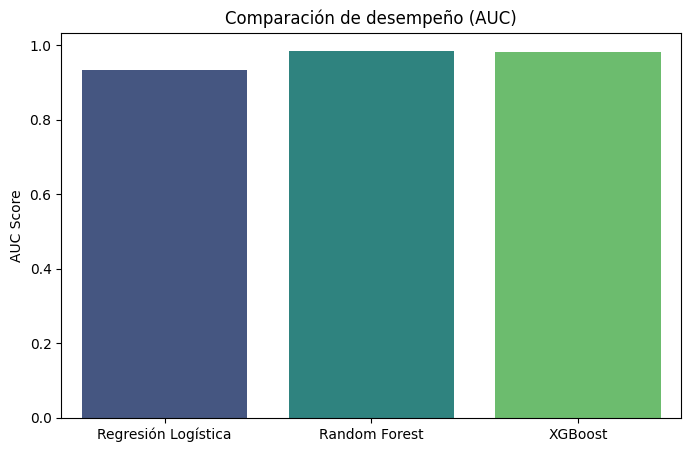

In [142]:
# ==========================================================
# 🚀 MODELOS OPTIMIZADOS SIN get_dummies
# ==========================================================
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================================
# 1️⃣ Dividir variables
# ==========================================================
df = base_balanceada_mod.copy()

# Variable objetivo
y = df['COMPENSADO'].astype(int)
X = df.drop(columns=['COMPENSADO'])

# Identificar variables numéricas y categóricas
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numéricas:", len(num_cols))
print("Categóricas:", len(cat_cols))

# Separar entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# ==========================================================
# 2️⃣ Preprocesadores
# ==========================================================
# Variables categóricas con baja cardinalidad (≤30)
cardinalidades = X_train[cat_cols].nunique().sort_values()
low_cat = cardinalidades[cardinalidades <= 30].index.tolist()
high_cat = cardinalidades[cardinalidades > 30].index.tolist()

# Para Regresión Logística
pre_lr = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat_low', OneHotEncoder(handle_unknown='ignore'), low_cat)
    ],
    remainder='drop'
)

# Para modelos de árboles (RF, XGB)
pre_tree = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_cols),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols)
    ],
    remainder='drop'
)

# ==========================================================
# 3️⃣ Definición de pipelines y grids
# ==========================================================
pipe_lr = Pipeline([
    ('prep', pre_lr),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

pipe_rf = Pipeline([
    ('prep', pre_tree),
    ('clf', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

pipe_xgb = Pipeline([
    ('prep', pre_tree),
    ('clf', XGBClassifier(eval_metric='logloss', random_state=42, tree_method='hist'))
])

# Parámetros
grid_lr = {'clf__C': [0.1, 1, 10], 'clf__solver': ['lbfgs', 'liblinear']}
grid_rf = {'clf__n_estimators': [100, 200], 'clf__max_depth': [8, 12], 'clf__min_samples_split': [2, 5]}
grid_xgb = {'clf__n_estimators': [200, 300], 'clf__learning_rate': [0.05, 0.1], 'clf__max_depth': [4, 6, 8]}

# ==========================================================
# 4️⃣ Entrenamiento y validación
# ==========================================================
def entrenar_y_evaluar(modelo, grid, nombre):
    search = GridSearchCV(modelo, grid, cv=5, n_jobs=-1, scoring='roc_auc', verbose=1)
    search.fit(X_train, y_train)
    best = search.best_estimator_
    y_pred = best.predict(X_test)
    y_proba = best.predict_proba(X_test)[:, 1]
    print(f"\n=== {nombre} ===")
    print("Mejores hiperparámetros:", search.best_params_)
    print("AUC:", roc_auc_score(y_test, y_proba))
    print(classification_report(y_test, y_pred))
    return roc_auc_score(y_test, y_proba)

auc_lr  = entrenar_y_evaluar(pipe_lr,  grid_lr,  "Regresión Logística")
auc_rf  = entrenar_y_evaluar(pipe_rf,  grid_rf,  "Random Forest")
auc_xgb = entrenar_y_evaluar(pipe_xgb, grid_xgb, "XGBoost")

# ==========================================================
# 5️⃣ Comparación gráfica
# ==========================================================
modelos = ['Regresión Logística', 'Random Forest', 'XGBoost']
auc_scores = [auc_lr, auc_rf, auc_xgb]

plt.figure(figsize=(8,5))
sns.barplot(x=modelos, y=auc_scores, palette='viridis')
plt.title('Comparación de desempeño (AUC)')
plt.ylabel('AUC Score')
plt.show()

Numéricas: 9
Categóricas: 17

Distribución y_train ANTES del balanceo (%):
COMPENSADO
0    85.906401
1    14.093599
Name: proportion, dtype: float64

Distribución y_train DESPUÉS del balanceo (2:1) (%):
__y__
0    66.666667
1    33.333333
Name: proportion, dtype: float64
Fitting 5 folds for each of 6 candidates, totalling 30 fits

=== Regresión Logística ===
Mejores hiperparámetros: {'clf__C': 10, 'clf__solver': 'liblinear'}
AUC: 0.9102782694710537
              precision    recall  f1-score   support

           0       0.96      0.89      0.93       686
           1       0.54      0.79      0.64       112

    accuracy                           0.88       798
   macro avg       0.75      0.84      0.78       798
weighted avg       0.90      0.88      0.89       798

Fitting 5 folds for each of 8 candidates, totalling 40 fits

=== Random Forest ===
Mejores hiperparámetros: {'clf__max_depth': 8, 'clf__min_samples_split': 2, 'clf__n_estimators': 200}
AUC: 0.9802035610162432
           

C:\Users\madelgado\AppData\Local\Temp\ipykernel_25508\918992069.py:143: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=modelos, y=auc_scores, palette='viridis')


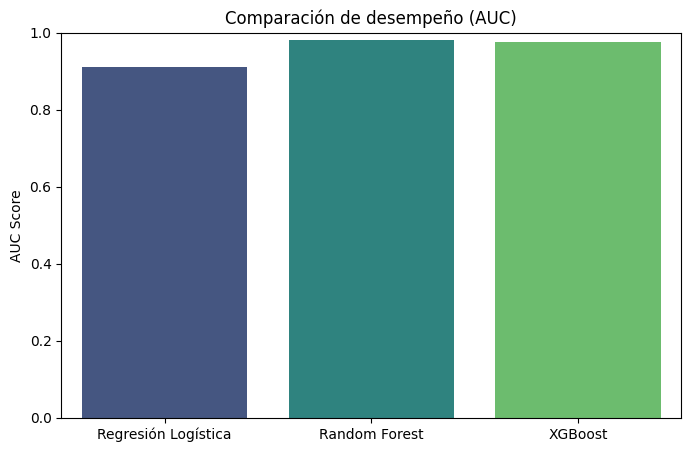

In [143]:
# ==========================================================
# 🚀 MODELOS OPTIMIZADOS SIN get_dummies
# ==========================================================
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.utils import resample  # <-- añadido para balanceo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================================
# 1️⃣ Dividir variables
# ==========================================================
df = base_final_limpia.copy()  # <-- ahora usa la base sin balancear

# Variable objetivo
y = df['COMPENSADO'].astype(int)
X = df.drop(columns=['COMPENSADO'])

# Identificar variables numéricas y categóricas
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numéricas:", len(num_cols))
print("Categóricas:", len(cat_cols))

# Separar entrenamiento y prueba (primero split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# ======= Balanceo SOLO en entrenamiento (downsampling 2:1) =======
def balancear_downsample(X_tr, y_tr, ratio_mayor_a_menor=2, random_state=42):
    tmp = X_tr.copy()
    tmp['__y__'] = y_tr.values if hasattr(y_tr, 'values') else y_tr
    may = tmp[tmp['__y__'] == 0]
    men = tmp[tmp['__y__'] == 1]

    if len(men) == 0 or len(may) == 0:
        # Si no hay ambas clases, regresar sin cambios
        tmp = tmp.sample(frac=1, random_state=random_state).reset_index(drop=True)
        return tmp.drop(columns='__y__'), tmp['__y__']

    n_target_may = min(len(may), len(men) * ratio_mayor_a_menor)
    may_down = resample(may, replace=False, n_samples=n_target_may, random_state=random_state)

    bal = pd.concat([may_down, men]).sample(frac=1, random_state=random_state).reset_index(drop=True)
    return bal.drop(columns='__y__'), bal['__y__']

print("\nDistribución y_train ANTES del balanceo (%):")
print((y_train.value_counts(normalize=True) * 100).rename('proportion'))

X_train_bal, y_train_bal = balancear_downsample(X_train, y_train, ratio_mayor_a_menor=2, random_state=42)

print("\nDistribución y_train DESPUÉS del balanceo (2:1) (%):")
print((y_train_bal.value_counts(normalize=True) * 100).rename('proportion'))

# ==========================================================
# 2️⃣ Preprocesadores
# ==========================================================
# Variables categóricas con baja/alta cardinalidad, calculadas en el TRAIN BALANCEADO
if cat_cols:
    cardinalidades = X_train_bal[cat_cols].nunique().sort_values()
    low_cat = cardinalidades[cardinalidades <= 30].index.tolist()
    high_cat = cardinalidades[cardinalidades > 30].index.tolist()
else:
    low_cat, high_cat = [], []

# Para Regresión Logística
pre_lr = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat_low', OneHotEncoder(handle_unknown='ignore'), low_cat)
    ],
    remainder='drop'
)

# Para modelos de árboles (RF, XGB)
pre_tree = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_cols),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols)
    ],
    remainder='drop'
)

# ==========================================================
# 3️⃣ Definición de pipelines y grids
# ==========================================================
pipe_lr = Pipeline([
    ('prep', pre_lr),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

pipe_rf = Pipeline([
    ('prep', pre_tree),
    ('clf', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

pipe_xgb = Pipeline([
    ('prep', pre_tree),
    ('clf', XGBClassifier(eval_metric='logloss', random_state=42, tree_method='hist'))
])

# Parámetros
grid_lr = {'clf__C': [0.1, 1, 10], 'clf__solver': ['lbfgs', 'liblinear']}
grid_rf = {'clf__n_estimators': [100, 200], 'clf__max_depth': [8, 12], 'clf__min_samples_split': [2, 5]}
grid_xgb = {'clf__n_estimators': [200, 300], 'clf__learning_rate': [0.05, 0.1], 'clf__max_depth': [4, 6, 8]}

# ==========================================================
# 4️⃣ Entrenamiento y validación
# ==========================================================
def entrenar_y_evaluar(modelo, grid, nombre):
    search = GridSearchCV(modelo, grid, cv=5, n_jobs=-1, scoring='roc_auc', verbose=1)
    search.fit(X_train_bal, y_train_bal)  # <-- ENTRENAR SOLO CON TRAIN BALANCEADO
    best = search.best_estimator_
    y_pred = best.predict(X_test)         # <-- EVALUAR EN TEST SIN TOCAR
    y_proba = best.predict_proba(X_test)[:, 1]
    print(f"\n=== {nombre} ===")
    print("Mejores hiperparámetros:", search.best_params_)
    print("AUC:", roc_auc_score(y_test, y_proba))
    print(classification_report(y_test, y_pred))
    return roc_auc_score(y_test, y_proba)

auc_lr  = entrenar_y_evaluar(pipe_lr,  grid_lr,  "Regresión Logística")
auc_rf  = entrenar_y_evaluar(pipe_rf,  grid_rf,  "Random Forest")
auc_xgb = entrenar_y_evaluar(pipe_xgb, grid_xgb, "XGBoost")

# ==========================================================
# 5️⃣ Comparación gráfica
# ==========================================================
modelos = ['Regresión Logística', 'Random Forest', 'XGBoost']
auc_scores = [auc_lr, auc_rf, auc_xgb]

plt.figure(figsize=(8,5))
sns.barplot(x=modelos, y=auc_scores, palette='viridis')
plt.title('Comparación de desempeño (AUC)')
plt.ylabel('AUC Score')
plt.ylim(0.0, 1.0)
plt.show()

### Espacio Fabian

### Espacio Cesar

### Espacio Maria